In [1]:
from pathlib import Path
import sys
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, linkage
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples, silhouette_score

sys.path.append("../")
from src.plots.maps import russia_plots
from src.static.hydro_atlas_analysis import (
    categorize_catchment_size,
    filter_hydroatlas_features,
    get_cluster_colors,
    get_cluster_markers,
    get_marker_size_corrections,
    get_size_categories,
)
from src.utils.logger import setup_logger

logger = setup_logger("hydroatlas_final", logger_name="../logs/hydroatlas_final.log")

gpd.options.io_engine = "pyogrio"
warnings.simplefilter(action="ignore", category=FutureWarning)

plt.rcParams["font.family"] = "DeJavu Serif"
plt.rcParams["font.serif"] = ["Times New Roman"]

# HydroATLAS Cluster Analysis - Final

Hierarchical clustering of Russian catchments based on HydroATLAS attributes.

**Dataset**: CAMELS-RU catchments < 50,000 km²  
**Method**: Ward linkage with Euclidean distance  
**Clusters**: 15 (based on dendrogram visual inspection)

## 1. Setup and Data Loading

In [2]:
# Load spatial data
ws = gpd.read_file("../data/Geometry/WatershedGeomCAMELS.gpkg")
ws.set_index("gauge_id", inplace=True)


gauge = gpd.read_file("../data/Geometry/GaugeGeomCAMELS.gpkg")
gauge.set_index("gauge_id", inplace=True)


basemap_data = gpd.read_file("../data/Geometry/basemap.gpkg")

logger.info(f"Loaded {len(gauge)} catchments < 50,000 km²")

2025-10-14 09:15:40 | INFO     | ../logs/hydroatlas_final.log | hydroatlas_final | ℹ️  Loaded 2638 catchments < 50,000 km²


## 2. Catchment Size Distribution

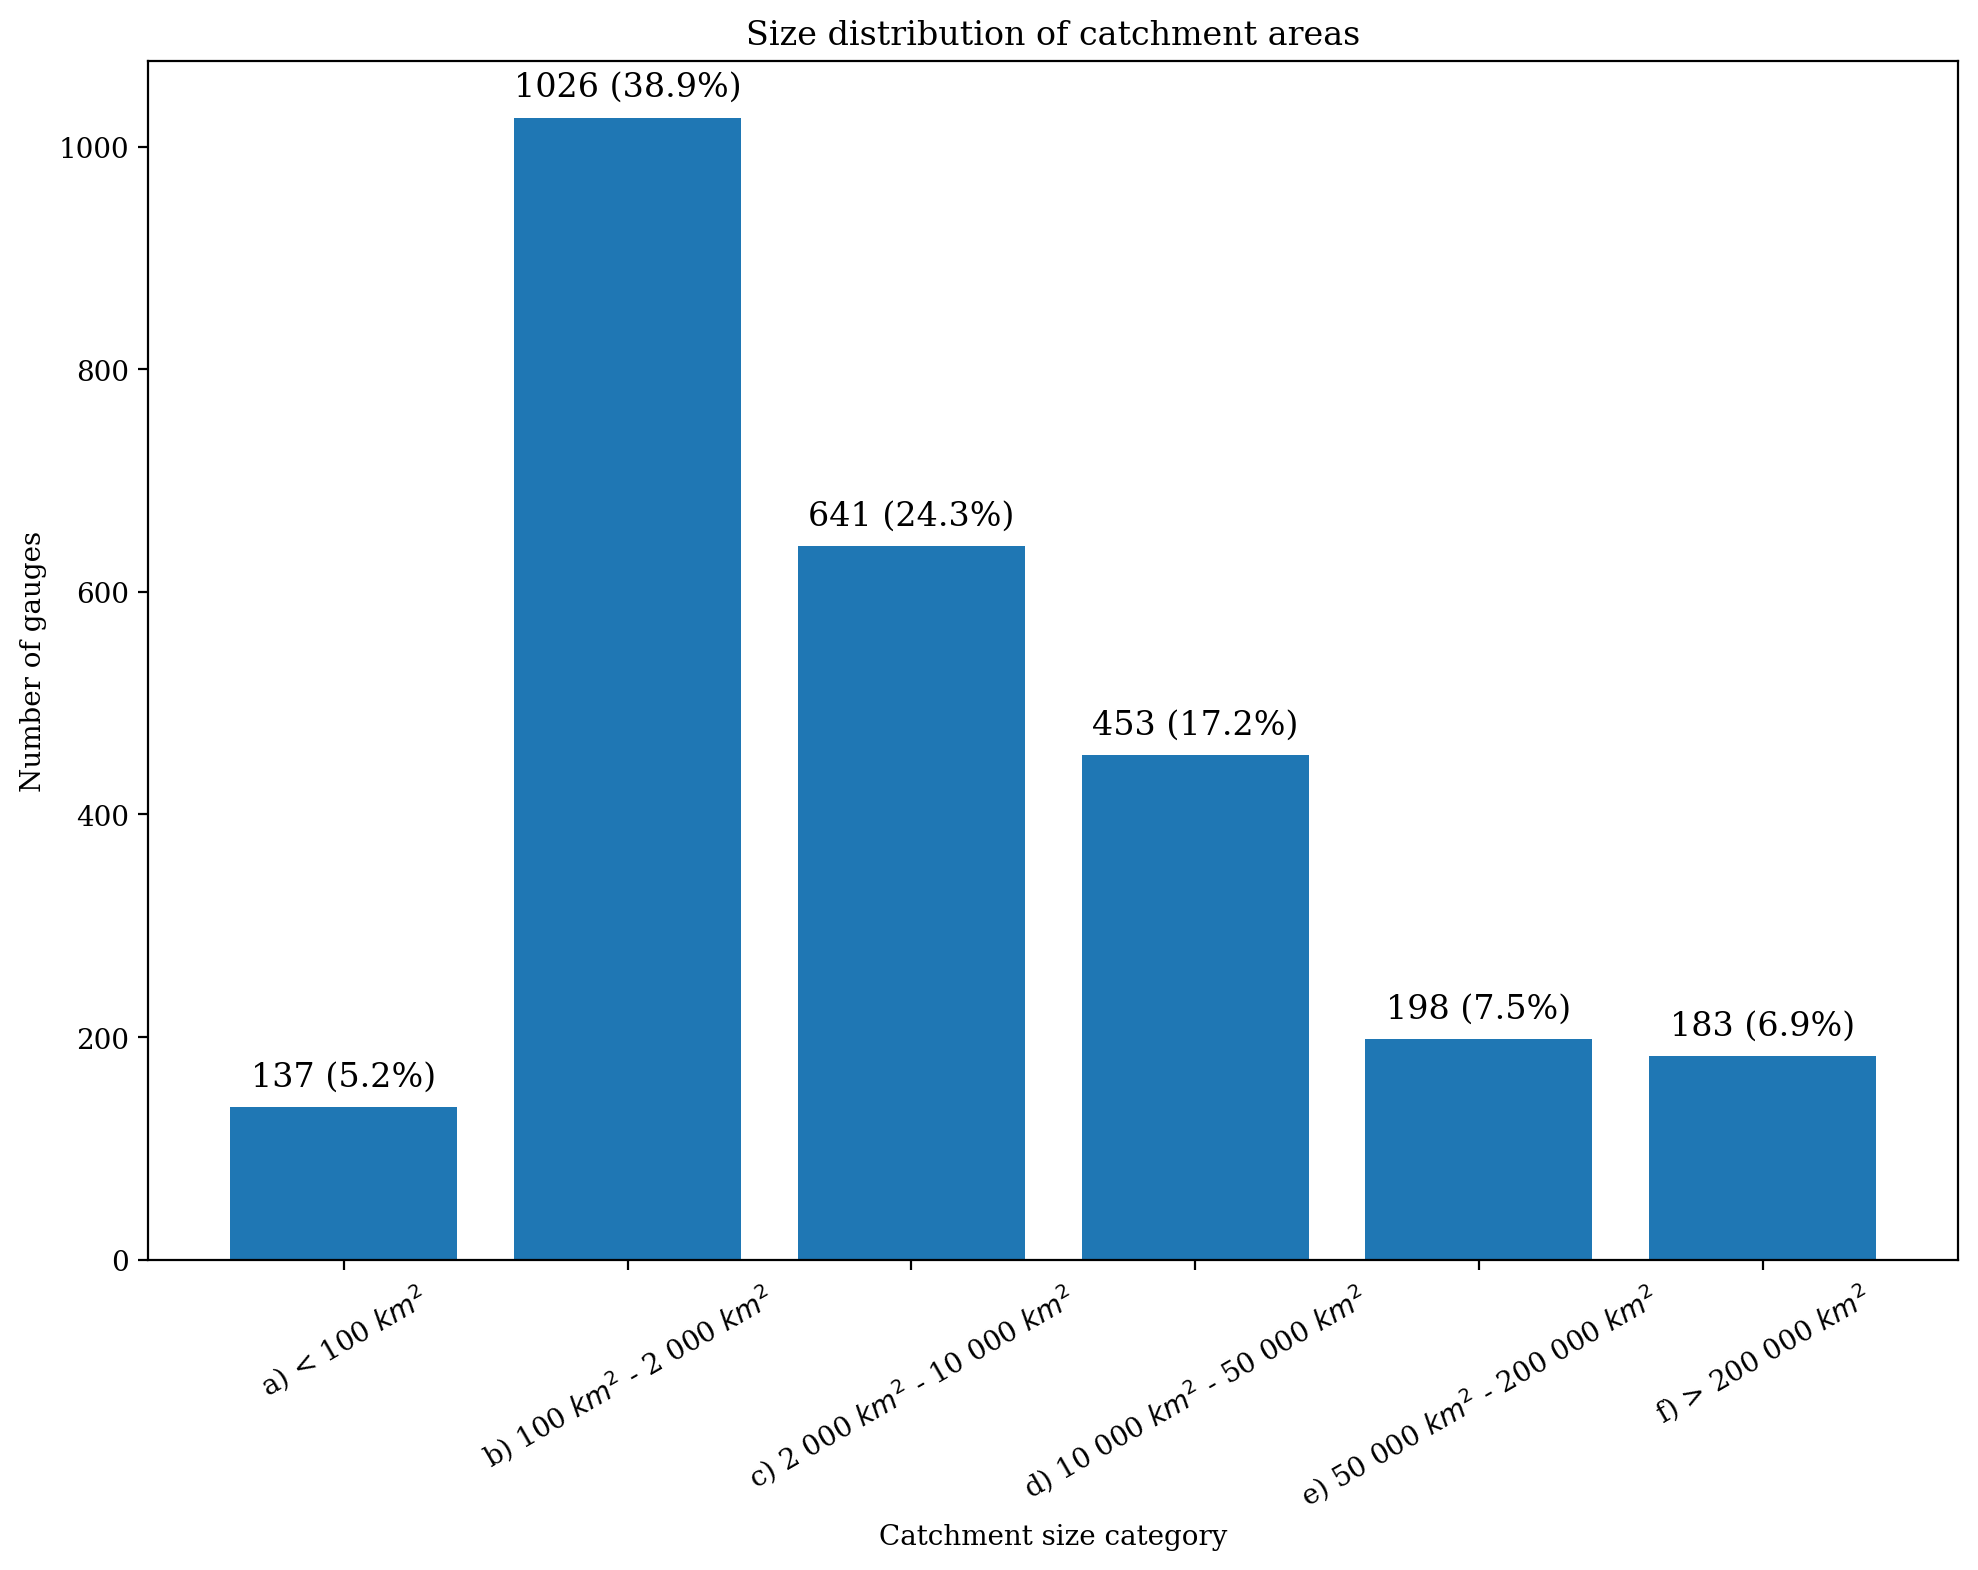

In [3]:
# Categorize by size
ws["size"] = ws["area"].apply(categorize_catchment_size)
ws["size"] = pd.Categorical(ws["size"], get_size_categories())

# Plot distribution
counts = ws["size"].value_counts(sort=False)
fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.bar(counts.index.astype(str), counts.values, color="C0")
ax.set_xlabel("Catchment size category")
ax.set_ylabel("Number of gauges")
ax.set_title("Size distribution of catchment areas")
ax.tick_params(axis="x", rotation=30)

total = counts.sum()
for rect, cnt in zip(bars, counts.values, strict=False):
    pct = cnt / total * 100
    ax.text(
        rect.get_x() + rect.get_width() / 2,
        rect.get_height() + total * 0.005,
        f"{cnt} ({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=12,
    )
fig.savefig("../paper/images/size_distribution_final.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [4]:
# Filter to only those < 50,000 km²
ws = ws.loc[ws["area"] < 50000, :]
gauge = gauge.loc[ws.index, :]
logger.info(f"Filtered to {len(gauge)} catchments < 50,000 km²")


2025-10-14 09:15:53 | INFO     | ../logs/hydroatlas_final.log | hydroatlas_final | ℹ️  Filtered to 2257 catchments < 50,000 km²


## 3. HydroATLAS Feature Processing

In [5]:
# Load HydroATLAS data
hydro_data = pd.read_csv(
    "../data/attributes/hydro_atlas_cis_camels.csv",
    index_col="gauge_id",
    dtype={"gauge_id": str},
)
mutual_index = pd.Index([i for i in gauge.index if i in hydro_data.index])
gauge = gauge.loc[mutual_index, :]
# Filter features by suffix and gauge index
hydro_subset, selected_features = filter_hydroatlas_features(hydro_data, mutual_index)

# Scale to 0-1 range
hydro_scaled = (hydro_subset - hydro_subset.min()) / (hydro_subset.max() - hydro_subset.min())
to_drop = [
    "slp_dg_uav",
    "sgr_dk_sav",
    "cmi_ix_uyr",
    "ari_ix_uav",
    "tmp_dc_uyr",
    "rdd_mk_uav",
    "swc_pc_uyr",
    "soc_th_uav",
    "ero_kh_uav",
    "hdi_ix_sav",
    "run_mm_syr",
    "nli_ix_uav",
]
# Drop redundant/correlated features
hydro_scaled = hydro_scaled.drop(to_drop, axis=1)
available_features = hydro_scaled.columns

logger.info(f"Selected {len(available_features)} HydroATLAS features")
print(f"Features: {list(available_features)}")

feature_descriptions = {
    "inu_pc_ult": {
        "name": "Inundation-prone",
        "description": "Inundated area % (ultimate upstream)",
        "suffix": "ult",
        "category": "Flood & Water Regulation",
        "hydrological_impact": "Flood risk, wetland presence, flow attenuation",
    },
    "lka_pc_use": {
        "name": "Lake coverage",
        "description": "Lake area % (upstream extent)",
        "suffix": "use",
        "category": "Flood & Water Regulation",
        "hydrological_impact": "Flow regulation, reduced variability, delayed response",
    },
    "gwt_cm_sav": {
        "name": "Groundwater depth",
        "description": "Groundwater table depth (area-weighted avg)",
        "suffix": "sav",
        "category": "Hydrogeology & Baseflow",
        "hydrological_impact": "Baseflow potential, aquifer recharge capacity",
    },
    "ele_mt_uav": {
        "name": "Elevation",
        "description": "Mean elevation (upstream area-weighted avg)",
        "suffix": "uav",
        "category": "Topography & Climate",
        "hydrological_impact": "Orographic precipitation, snowmelt regime, steep gradients",
    },
    "pre_mm_uyr": {
        "name": "Precipitation",
        "description": "Annual precipitation (upstream yearly)",
        "suffix": "uyr",
        "category": "Topography & Climate",
        "hydrological_impact": "Primary water input, controls runoff generation",
    },
    "pet_mm_uyr": {
        "name": "Potential ET",
        "description": "Potential evapotranspiration (upstream yearly)",
        "suffix": "uyr",
        "category": "Topography & Climate",
        "hydrological_impact": "Atmospheric water demand, aridity indicator",
    },
    "aet_mm_uyr": {
        "name": "Actual ET",
        "description": "Actual evapotranspiration (upstream yearly)",
        "suffix": "uyr",
        "category": "Topography & Climate",
        "hydrological_impact": "Actual water loss, controls water balance",
    },
    "snw_pc_uyr": {
        "name": "Snow cover",
        "description": "Snow cover percentage (upstream yearly)",
        "suffix": "uyr",
        "category": "Topography & Climate",
        "hydrological_impact": "Snowmelt regime, seasonal flow patterns",
    },
    "for_pc_use": {
        "name": "Forest",
        "description": "Forest cover % (upstream extent)",
        "suffix": "use",
        "category": "Land Cover & Human Impact",
        "hydrological_impact": "Evapotranspiration, runoff moderation, canopy interception",
    },
    "crp_pc_use": {
        "name": "Cropland",
        "description": "Cropland % (upstream extent)",
        "suffix": "use",
        "category": "Land Cover & Human Impact",
        "hydrological_impact": "Seasonal variability, irrigation, nutrient transport",
    },
    "pst_pc_use": {
        "name": "Pasture",
        "description": "Pasture % (upstream extent)",
        "suffix": "use",
        "category": "Land Cover & Human Impact",
        "hydrological_impact": "Moderate infiltration, grazing impacts on soil",
    },
    "ire_pc_use": {
        "name": "Irrigated area",
        "description": "Irrigated area % (upstream extent)",
        "suffix": "use",
        "category": "Land Cover & Human Impact",
        "hydrological_impact": "Water abstraction, altered flow regime",
    },
    "gla_pc_use": {
        "name": "Glacier",
        "description": "Glacier area % (upstream extent)",
        "suffix": "use",
        "category": "Cryosphere",
        "hydrological_impact": "Glacial melt contribution, climate-sensitive hydrology",
    },
    "prm_pc_use": {
        "name": "Permafrost",
        "description": "Permafrost % (upstream extent)",
        "suffix": "use",
        "category": "Cryosphere",
        "hydrological_impact": "Restricted infiltration, high surface runoff, extreme seasonality",
    },
    "pac_pc_use": {
        "name": "Protected areas",
        "description": "Protected areas % (upstream extent)",
        "suffix": "use",
        "category": "Land Cover & Human Impact",
        "hydrological_impact": "Limited human impact, natural flow regimes",
    },
    "cly_pc_uav": {
        "name": "Clay content",
        "description": "Clay content % (upstream area-weighted avg)",
        "suffix": "uav",
        "category": "Soil Properties",
        "hydrological_impact": "Low infiltration, high surface runoff",
    },
    "slt_pc_uav": {
        "name": "Silt content",
        "description": "Silt content % (upstream area-weighted avg)",
        "suffix": "uav",
        "category": "Soil Properties",
        "hydrological_impact": "Moderate infiltration, erosion susceptibility",
    },
    "snd_pc_uav": {
        "name": "Sand content",
        "description": "Sand content % (upstream area-weighted avg)",
        "suffix": "uav",
        "category": "Soil Properties",
        "hydrological_impact": "High infiltration, groundwater recharge",
    },
    "kar_pc_use": {
        "name": "Karst",
        "description": "Karst area % (upstream extent)",
        "suffix": "use",
        "category": "Hydrogeology & Baseflow",
        "hydrological_impact": "Subsurface flow dominance, spring-fed baseflow",
    },
    "ppd_pk_uav": {
        "name": "Population density",
        "description": "Population density (upstream area-weighted avg)",
        "suffix": "uav",
        "category": "Land Cover & Human Impact",
        "hydrological_impact": "Anthropogenic pressure, water demand, pollution risk",
    },
    "urb_pc_use": {
        "name": "Urban area",
        "description": "Urban area % (upstream extent)",
        "suffix": "use",
        "category": "Land Cover & Human Impact",
        "hydrological_impact": "Rapid runoff, flashy hydrographs, reduced baseflow",
    },
    "gdp_ud_sav": {
        "name": "GDP density",
        "description": "GDP density (sub-basin area-weighted avg)",
        "suffix": "sav",
        "category": "Land Cover & Human Impact",
        "hydrological_impact": "Economic activity, infrastructure development, water use intensity",
    },
}

# Create DataFrame for display
feature_df = pd.DataFrame.from_dict(feature_descriptions, orient="index")
feature_df.index.name = "HydroATLAS Code"
feature_df = feature_df.reset_index()

# Reorder columns
feature_df = feature_df[
    [
        "HydroATLAS Code",
        "name",
        "description",
        "suffix",
        "category",
        "hydrological_impact",
    ]
]

# Rename columns for clarity
feature_df.columns = [
    "HydroATLAS Code",
    "Short Name",
    "Full Description",
    "Suffix",
    "Category",
    "Hydrological Impact",
]

feature_df

2025-10-14 09:16:02 | INFO     | ../logs/hydroatlas_final.log | hydroatlas_final | ℹ️  Selected 22 HydroATLAS features


Features: ['inu_pc_ult', 'lka_pc_use', 'gwt_cm_sav', 'ele_mt_uav', 'pre_mm_uyr', 'pet_mm_uyr', 'aet_mm_uyr', 'snw_pc_uyr', 'for_pc_use', 'crp_pc_use', 'pst_pc_use', 'ire_pc_use', 'gla_pc_use', 'prm_pc_use', 'pac_pc_use', 'cly_pc_uav', 'slt_pc_uav', 'snd_pc_uav', 'kar_pc_use', 'ppd_pk_uav', 'urb_pc_use', 'gdp_ud_sav']


,HydroATLAS Code,Short Name,Full Description,Suffix,Category,Hydrological Impact
0,inu_pc_ult,Inundation-prone,Inundated area % (ultimate upstream),ult,Flood & Water Regulation,"Flood risk, wetland presence, flow attenuation"
1,lka_pc_use,Lake coverage,Lake area % (upstream extent),use,Flood & Water Regulation,"Flow regulation, reduced variability, delayed ..."
2,gwt_cm_sav,Groundwater depth,Groundwater table depth (area-weighted avg),sav,Hydrogeology & Baseflow,"Baseflow potential, aquifer recharge capacity"
3,ele_mt_uav,Elevation,Mean elevation (upstream area-weighted avg),uav,Topography & Climate,"Orographic precipitation, snowmelt regime, ste..."
4,pre_mm_uyr,Precipitation,Annual precipitation (upstream yearly),uyr,Topography & Climate,"Primary water input, controls runoff generation"
5,pet_mm_uyr,Potential ET,Potential evapotranspiration (upstream yearly),uyr,Topography & Climate,"Atmospheric water demand, aridity indicator"
6,aet_mm_uyr,Actual ET,Actual evapotranspiration (upstream yearly),uyr,Topography & Climate,"Actual water loss, controls water balance"
7,snw_pc_uyr,Snow cover,Snow cover percentage (upstream yearly),uyr,Topography & Climate,"Snowmelt regime, seasonal flow patterns"
8,for_pc_use,Forest,Forest cover % (upstream extent),use,Land Cover & Human Impact,"Evapotranspiration, runoff moderation, canopy ..."
9,crp_pc_use,Cropland,Cropland % (upstream extent),use,Land Cover & Human Impact,"Seasonal variability, irrigation, nutrient tra..."


## 4. Hierarchical Clustering with Ward Method

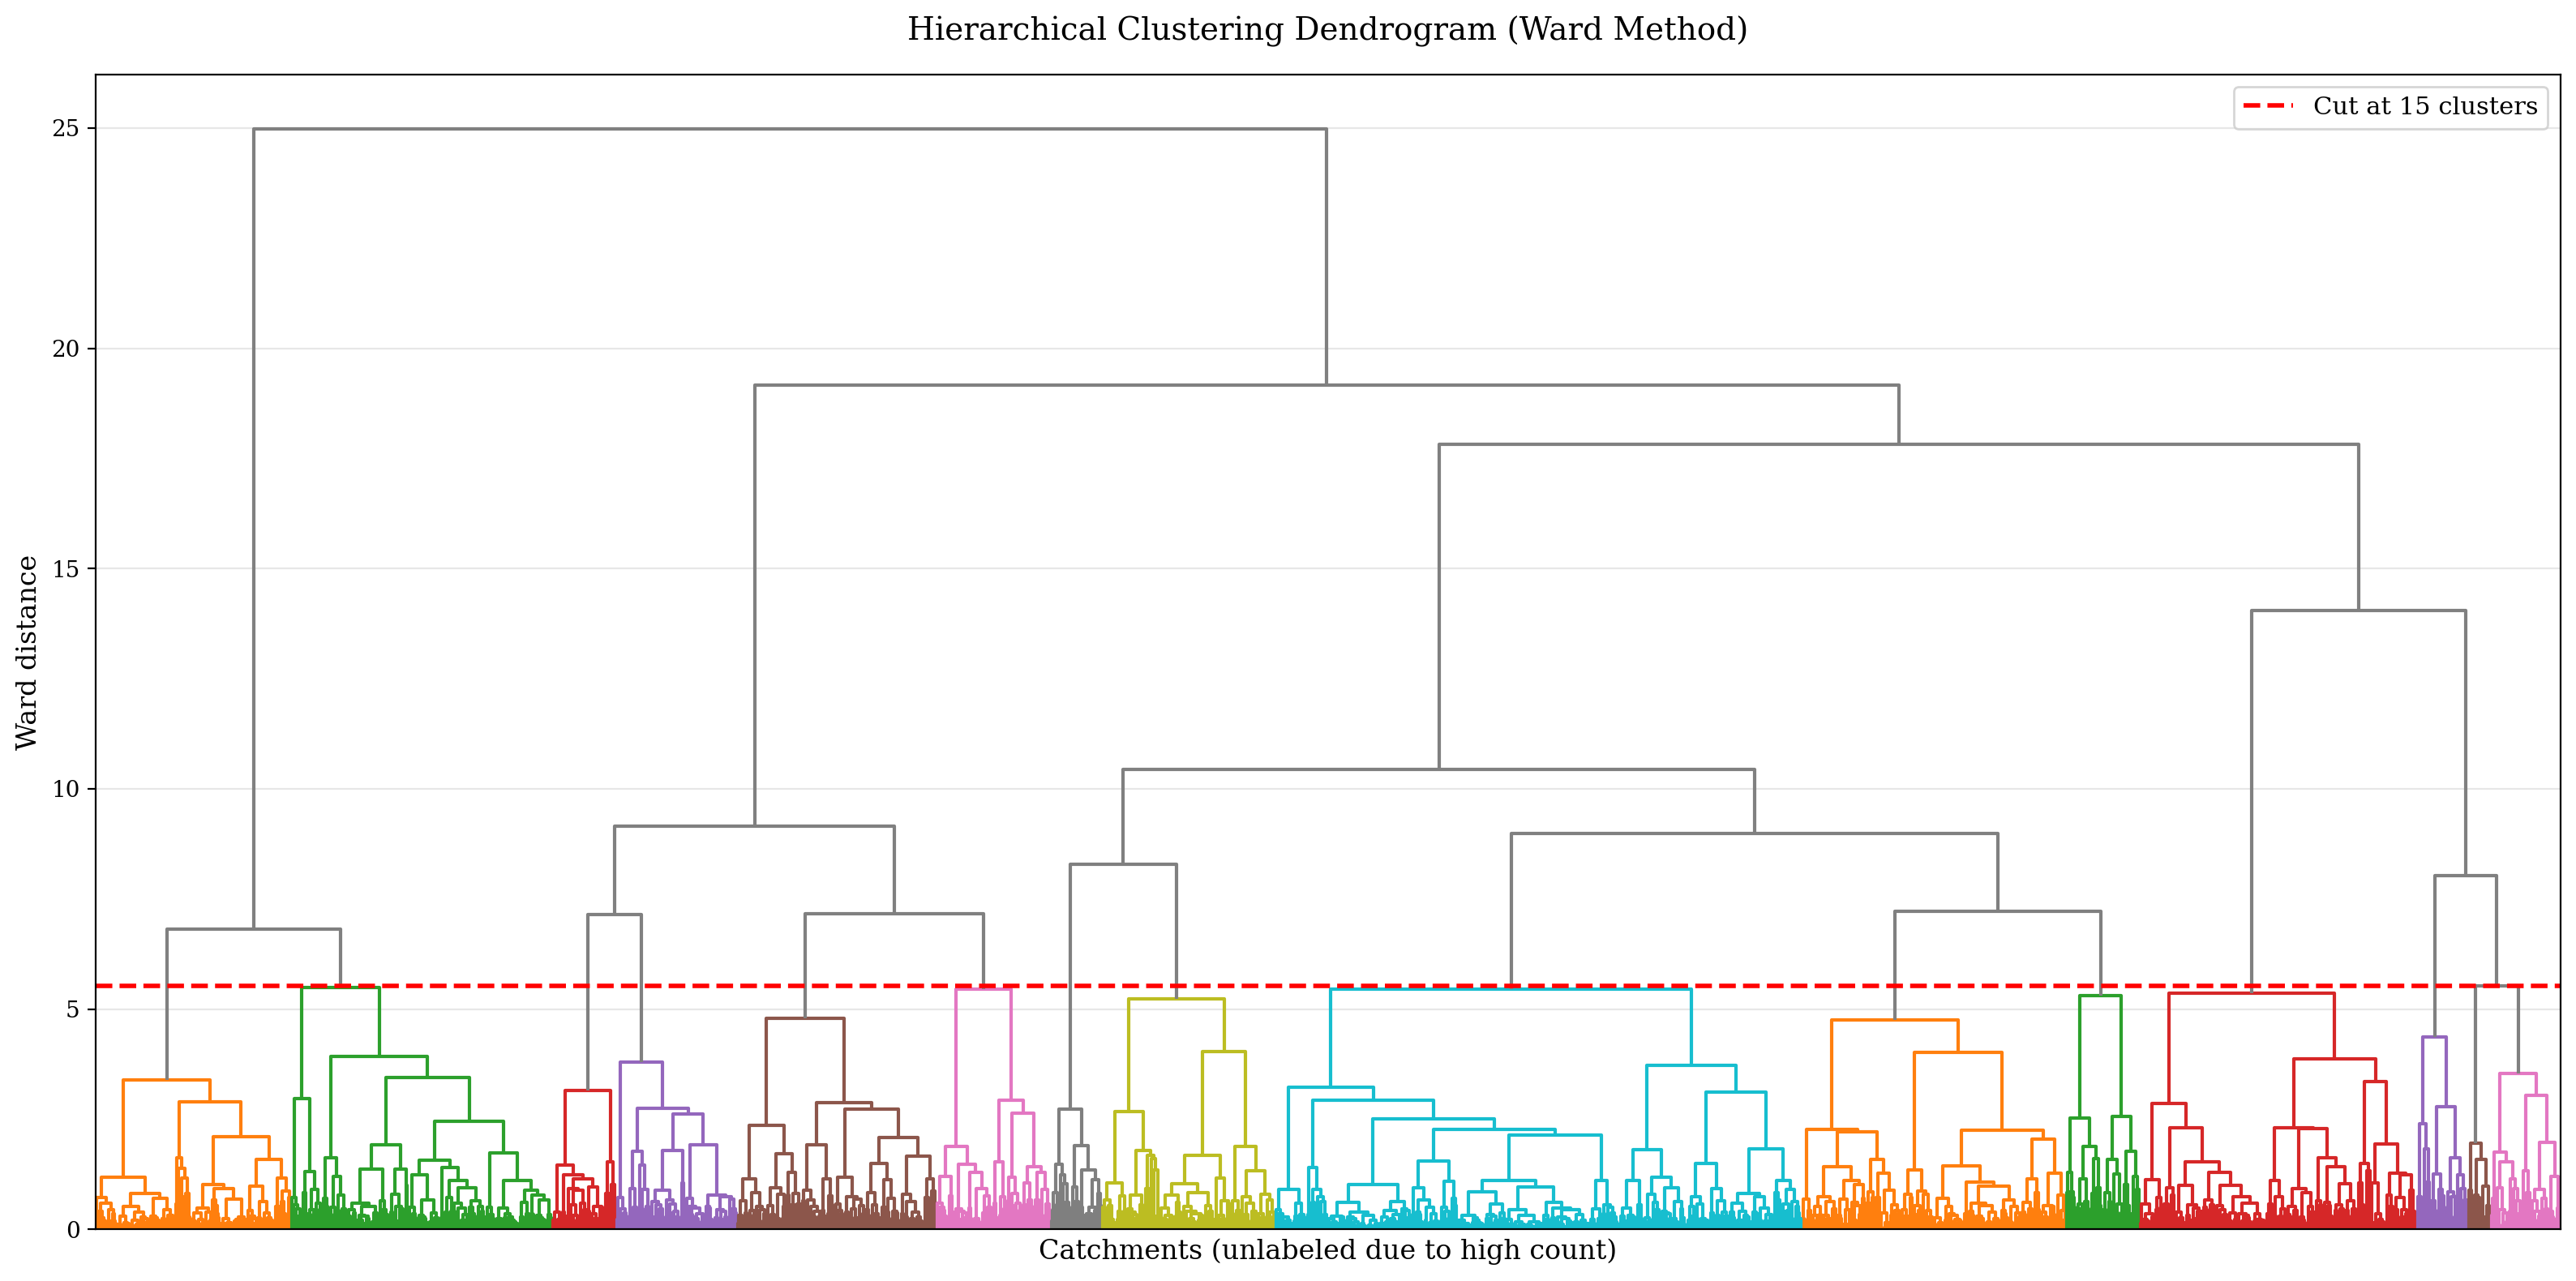

In [6]:
cluster_number = 15
# Compute linkage matrix
Z = linkage(hydro_scaled.values, method="ward", metric="euclidean")

# Plot dendrogram (without x-axis labels due to many gauges)
fig, ax = plt.subplots(figsize=(16, 8))
dendro = dendrogram(
    Z,
    ax=ax,
    above_threshold_color="#808080",
    color_threshold=Z[-cluster_number + 1, 2],
    no_labels=True,  # Don't show gauge IDs on x-axis
)

ax.set_xlabel("Catchments (unlabeled due to high count)", fontsize=12)
ax.set_ylabel("Ward distance", fontsize=12)
ax.set_title("Hierarchical Clustering Dendrogram (Ward Method)", fontsize=14, pad=15)
ax.axhline(
    y=Z[-cluster_number + 1, 2],
    color="r",
    linestyle="--",
    linewidth=2,
    label=f"Cut at {cluster_number} clusters",
)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

fig.savefig(
    f"../paper/images/geo_dendrogram_ward_{cluster_number}_clusters.png", dpi=300, bbox_inches="tight"
)
plt.tight_layout()
plt.show()

## 5. Extract 15 Clusters and Compute Centroids

In [7]:
# Extract cluster labels (1-based indexing)
from scipy.cluster.hierarchy import fcluster

hierarchical_labels = fcluster(Z, t=cluster_number, criterion="maxclust")

# Add to dataframes
hydro_scaled["Cluster_HC"] = hierarchical_labels
gauge["Cluster_HC"] = hierarchical_labels

# Compute cluster centroids (0-1 normalized values)
cluster_centroids = hydro_scaled.groupby("Cluster_HC")[available_features].mean()

# Compute raw (original scale) centroids for interpretation
hydro_subset["Cluster_HC"] = hierarchical_labels
cluster_centroids_raw = hydro_subset.groupby("Cluster_HC")[available_features].mean()


## 6. Cluster Validation Metrics

In [8]:
# Compute silhouette scores
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

# CRITICAL: Use only feature columns, exclude Cluster_HC
scaled_values = hydro_scaled[available_features].values
silhouette_avg = silhouette_score(scaled_values, hierarchical_labels)
silhouette_vals = silhouette_samples(scaled_values, hierarchical_labels)

ch_score = calinski_harabasz_score(scaled_values, hierarchical_labels)
db_score = davies_bouldin_score(scaled_values, hierarchical_labels)

print(f"Clustering validation metrics (k={cluster_number}):")
print(f"  Silhouette Score: {silhouette_avg:.3f}")
print(f"  Calinski-Harabasz: {ch_score:.1f}")
print(f"  Davies-Bouldin: {db_score:.3f}")

# Per-cluster silhouette
for cluster_id in range(1, cluster_number + 1):
    cluster_mask = hierarchical_labels == cluster_id
    cluster_sil = silhouette_vals[cluster_mask].mean()
    n_samples = cluster_mask.sum()
    print(f"  Cluster {cluster_id}: silhouette={cluster_sil:.3f}, n={n_samples}")

Clustering validation metrics (k=15):
  Silhouette Score: 0.194
  Calinski-Harabasz: 314.9
  Davies-Bouldin: 1.459
  Cluster 1: silhouette=0.368, n=179
  Cluster 2: silhouette=0.029, n=238
  Cluster 3: silhouette=0.371, n=59
  Cluster 4: silhouette=0.262, n=110
  Cluster 5: silhouette=0.159, n=182
  Cluster 6: silhouette=0.062, n=105
  Cluster 7: silhouette=0.357, n=46
  Cluster 8: silhouette=0.121, n=159
  Cluster 9: silhouette=0.261, n=480
  Cluster 10: silhouette=0.076, n=242
  Cluster 11: silhouette=-0.004, n=67
  Cluster 12: silhouette=0.244, n=253
  Cluster 13: silhouette=0.146, n=47
  Cluster 14: silhouette=0.418, n=21
  Cluster 15: silhouette=0.314, n=63


## 7. PCA Visualization

Variance explained by principal components:
  PC1: 29.62% (cumulative: 29.62%)
  PC2: 18.64% (cumulative: 48.26%)
  PC3: 14.67% (cumulative: 62.93%)
  PC4: 8.09% (cumulative: 71.02%)
  PC5: 6.67% (cumulative: 77.69%)


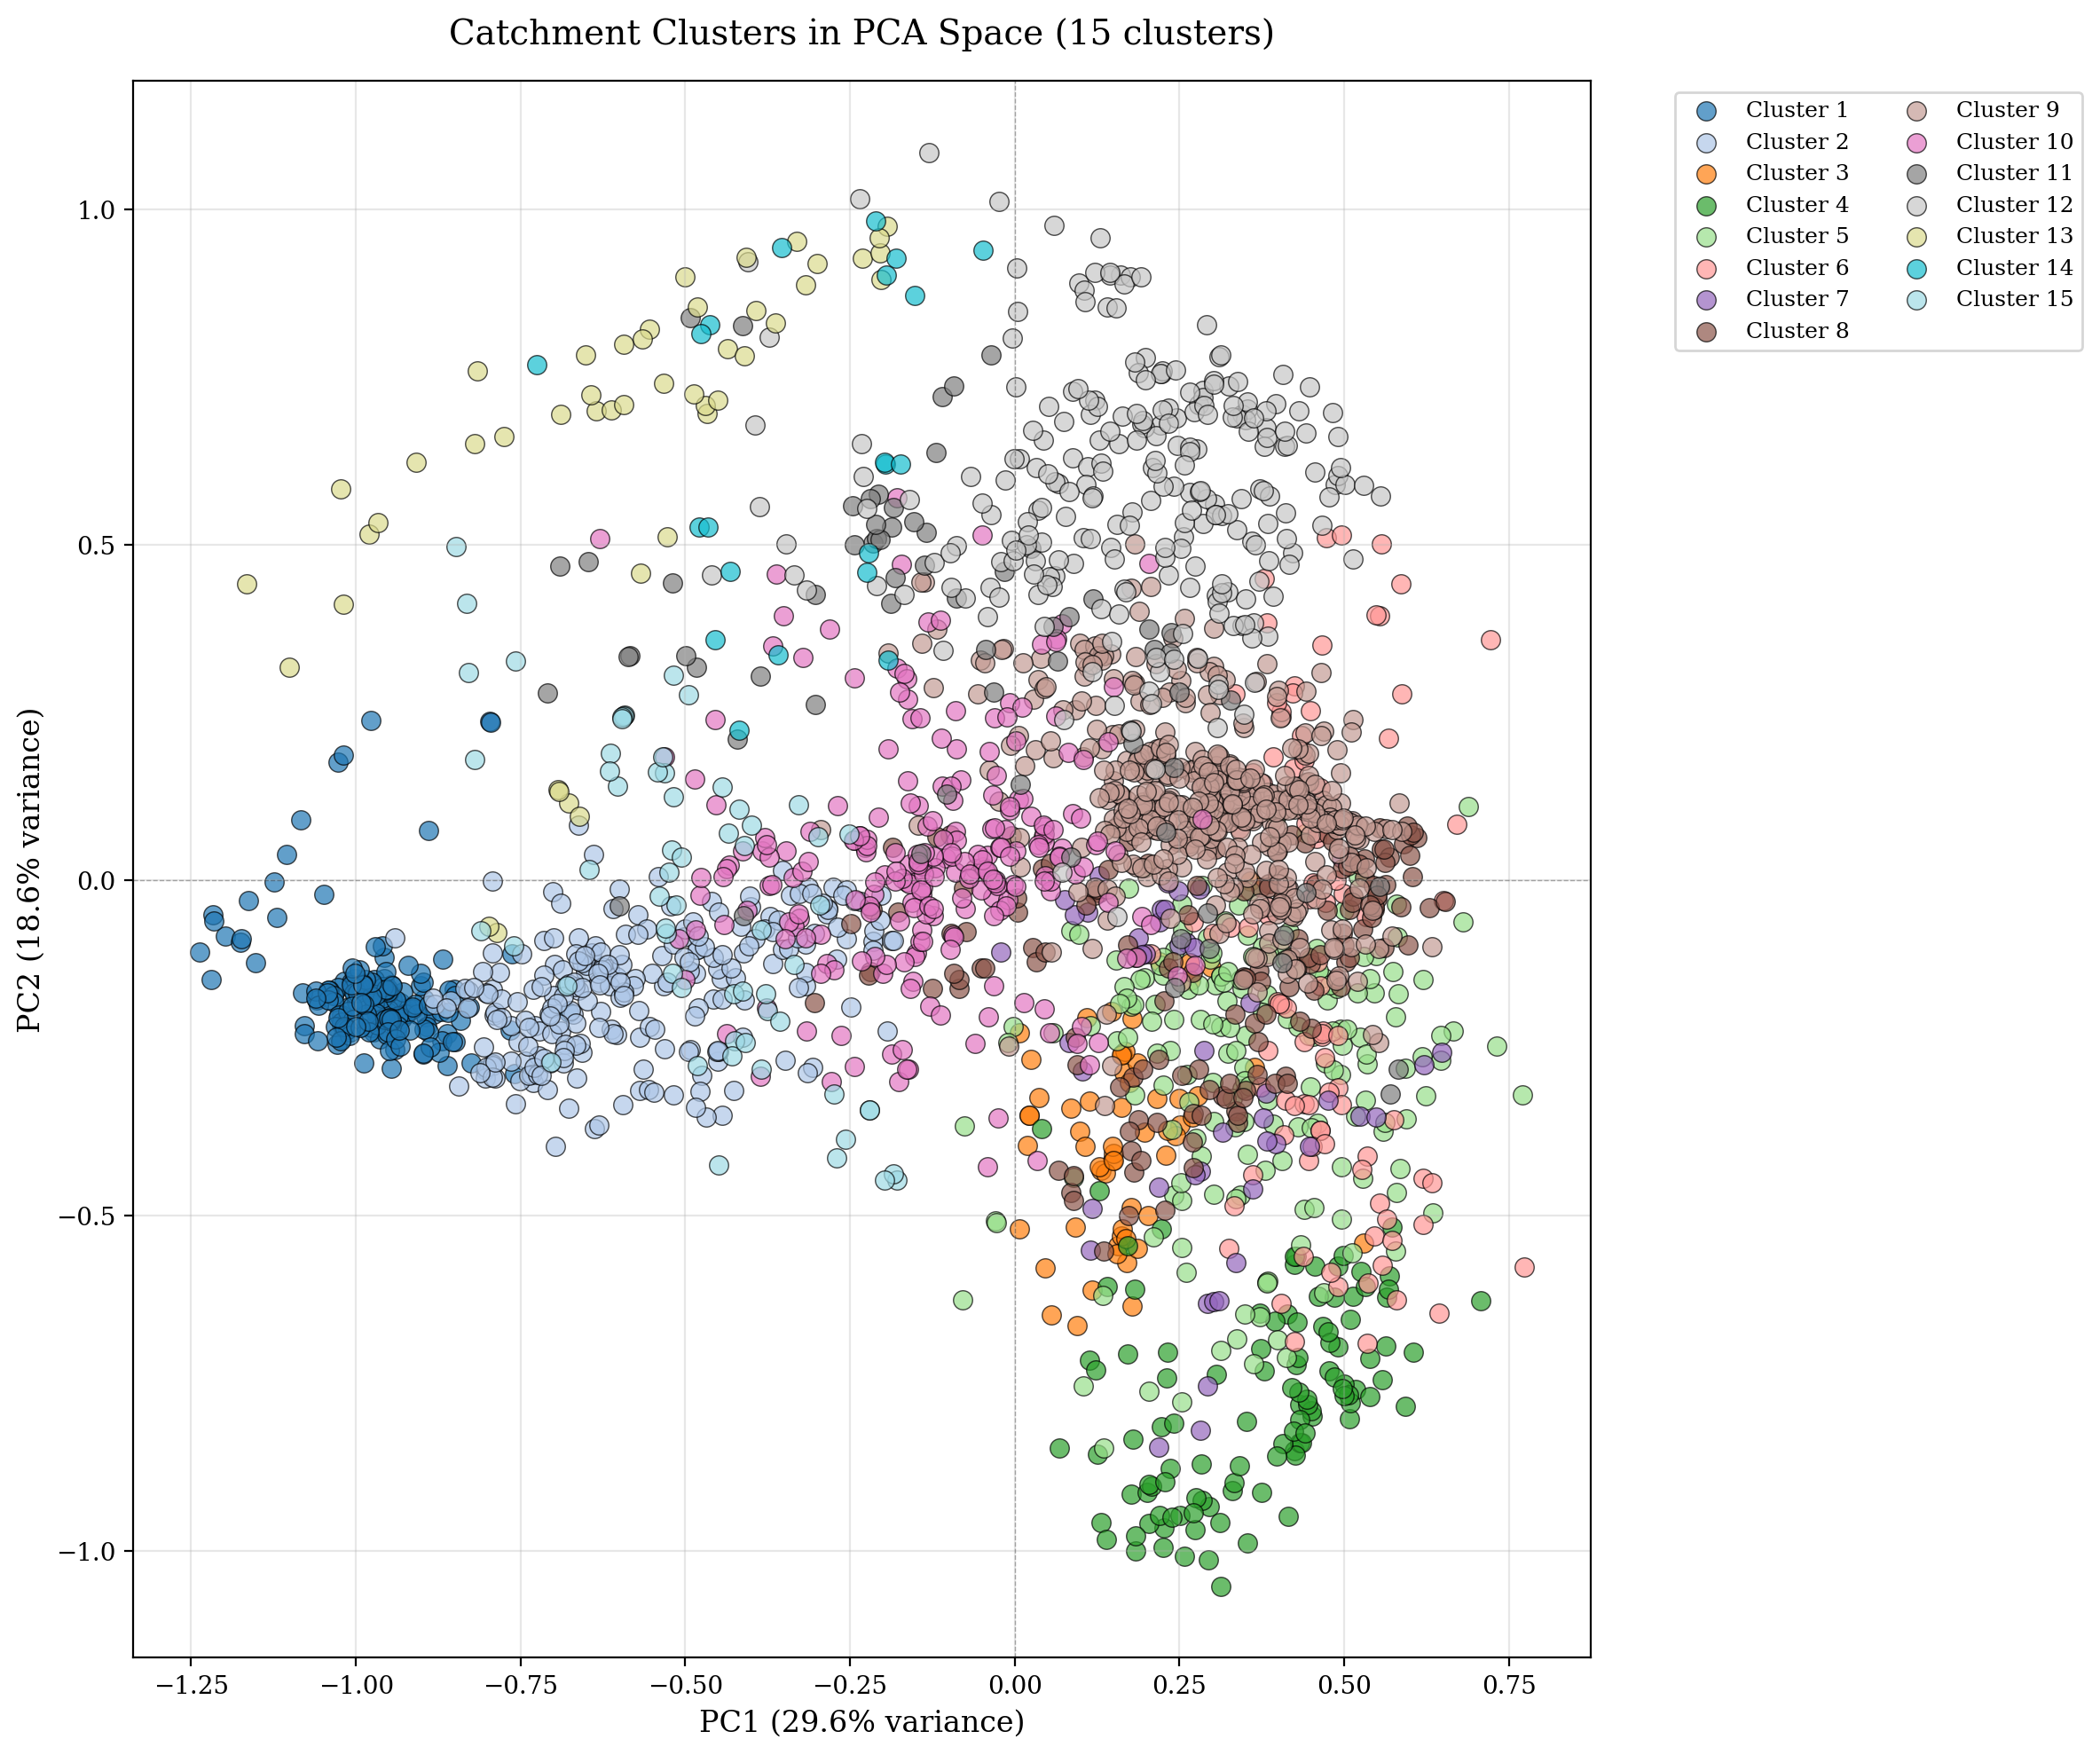

In [9]:
# Perform PCA on feature columns only (exclude Cluster_HC)
pca = PCA(n_components=min(10, len(available_features)))
pca_features = pca.fit_transform(scaled_values)

pca_df = pd.DataFrame(
    pca_features,
    columns=[f"PC{i + 1}" for i in range(pca.n_components_)],
    index=hydro_scaled.index,
)
pca_df["Cluster_HC"] = hierarchical_labels

variance_explained = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(variance_explained)

# Print variance explained by first few components
print("Variance explained by principal components:")
for i in range(min(5, pca.n_components_)):
    print(
        f"  PC{i + 1}: {variance_explained[i] * 100:.2f}% (cumulative: {cumulative_variance[i] * 100:.2f}%)"
    )

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
cmap = plt.get_cmap("tab20", cluster_number)
colors_pca = [cmap(i) for i in range(cluster_number)]

for cluster_id in range(1, cluster_number + 1):
    cluster_mask = pca_df["Cluster_HC"] == cluster_id
    cluster_data = pca_df[cluster_mask]

    ax.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        c=[colors_pca[cluster_id - 1]],
        label=f"Cluster {cluster_id}",
        s=60,
        alpha=0.7,
        edgecolors="black",
        linewidth=0.5,
    )

ax.set_xlabel(f"PC1 ({variance_explained[0] * 100:.1f}% variance)", fontsize=12)
ax.set_ylabel(f"PC2 ({variance_explained[1] * 100:.1f}% variance)", fontsize=12)
ax.set_title(f"Catchment Clusters in PCA Space ({cluster_number} clusters)", fontsize=14, pad=15)
ax.axhline(y=0, color="k", linestyle="--", linewidth=0.5, alpha=0.3)
ax.axvline(x=0, color="k", linestyle="--", linewidth=0.5, alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)

fig.savefig(f"../paper/images/geo_pca_{cluster_number}_clusters.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

## 9. Cluster Heatmap

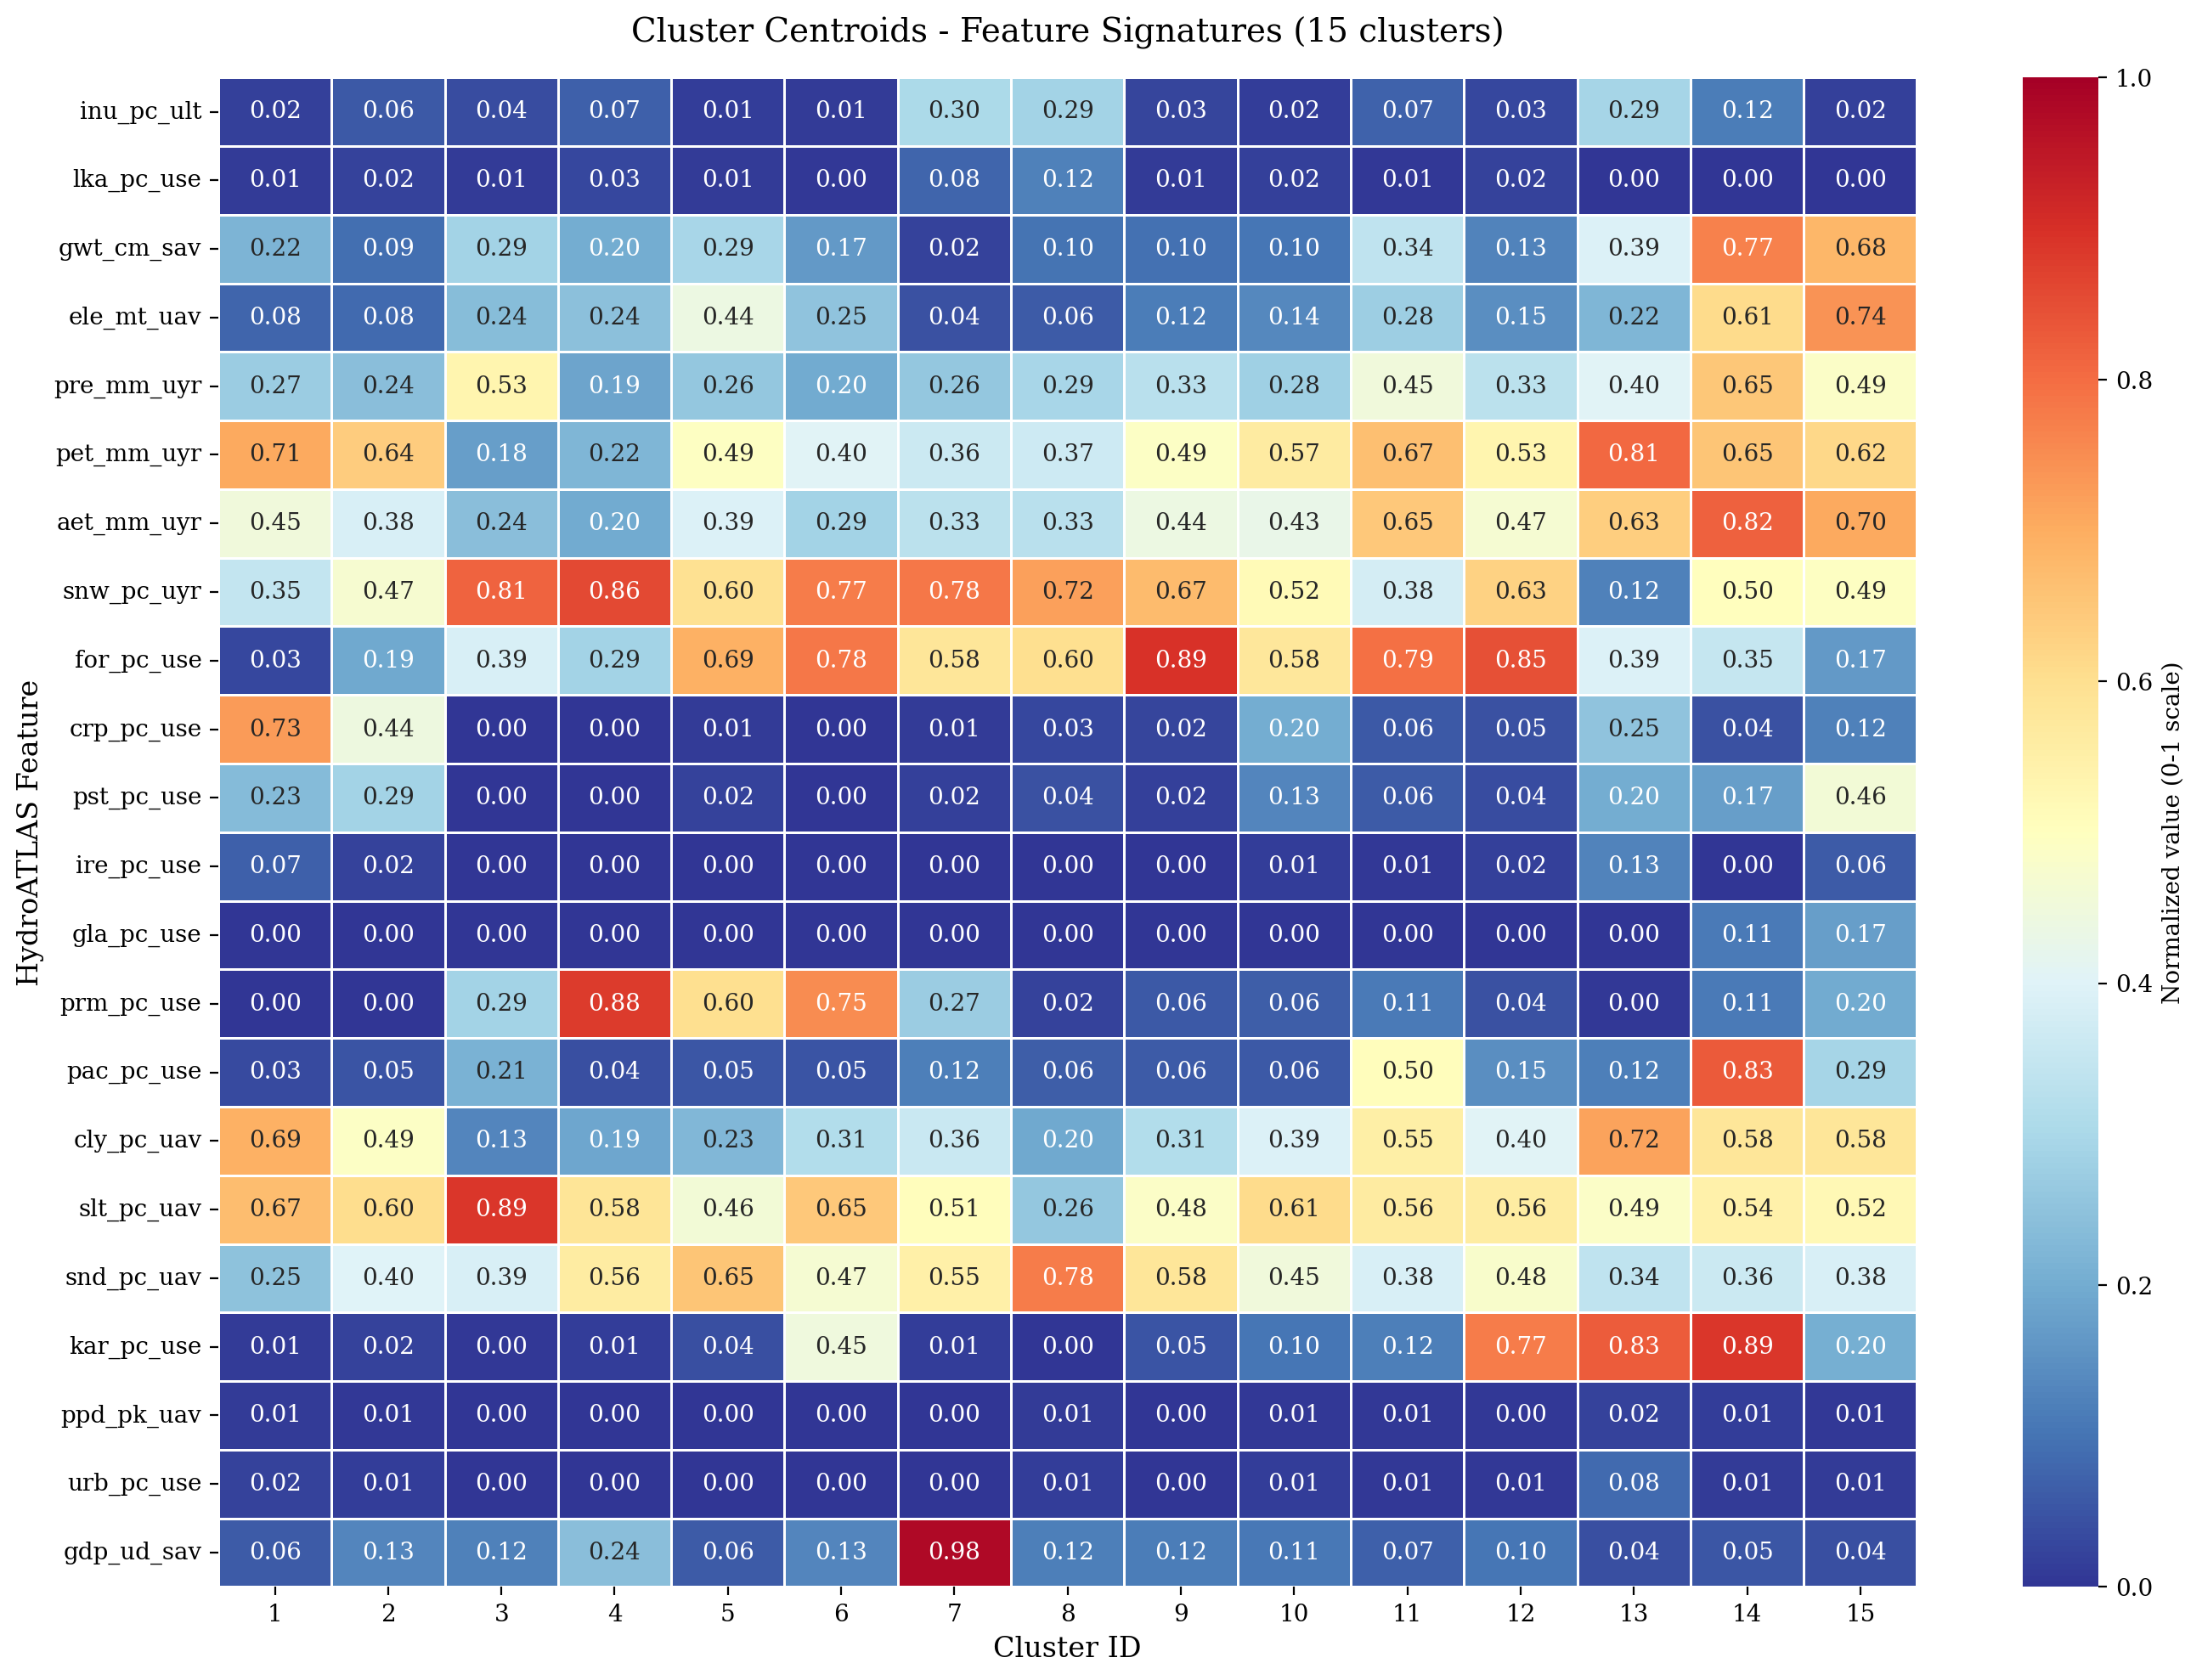

In [10]:
# Plot heatmap with 0-1 normalized values
fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    cluster_centroids.T,
    cmap="RdYlBu_r",
    center=0.5,
    vmin=0,
    vmax=1,
    annot=True,
    fmt=".2f",
    cbar_kws={"label": "Normalized value (0-1 scale)"},
    linewidths=0.5,
    ax=ax,
)

ax.set_xlabel("Cluster ID", fontsize=12)
ax.set_ylabel("HydroATLAS Feature", fontsize=12)
ax.set_title(f"Cluster Centroids - Feature Signatures ({cluster_number} clusters)", fontsize=14, pad=15)

fig.savefig(f"../paper/images/geo_cluster_heatmap_{cluster_number}.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()


## 10. Export Results

In [11]:
# Export cluster assignments
output_path = Path(f"../paper/tables/geo_catchment_clusters_{cluster_number}_final.csv")
export_df = pd.DataFrame(
    {
        "gauge_id": hydro_scaled.index,
        "cluster_id": hierarchical_labels,
        "cluster_name": [f"Cluster {cl}" for cl in hierarchical_labels],
        "silhouette_score": silhouette_vals,
    }
)
export_df.to_csv(output_path, index=False)

# Export cluster centroids (both normalized and raw)
centroids_path_norm = Path(f"../paper/tables/geo_cluster_centroids_{cluster_number}_normalized.csv")
centroids_path_raw = Path(f"../paper/tables/geo_cluster_centroids_{cluster_number}_raw.csv")

cluster_centroids.to_csv(centroids_path_norm)
cluster_centroids_raw.to_csv(centroids_path_raw)

print(f"Exported cluster assignments to: {output_path}")
print(f"Exported normalized centroids to: {centroids_path_norm}")
print(f"Exported raw centroids to: {centroids_path_raw}")

logger.info(f"Analysis complete: {cluster_number} clusters identified")


2025-10-14 09:17:11 | INFO     | ../logs/hydroatlas_final.log | hydroatlas_final | ℹ️  Analysis complete: 15 clusters identified


Exported cluster assignments to: ../paper/tables/geo_catchment_clusters_15_final.csv
Exported normalized centroids to: ../paper/tables/geo_cluster_centroids_15_normalized.csv
Exported raw centroids to: ../paper/tables/geo_cluster_centroids_15_raw.csv


Generated cluster names:
  Cluster 1 (n=179): Cropland (64.0%) / Clay-rich
  Cluster 2 (n=238): Lowland (228m) / Moderate (493mm/yr)
  Cluster 3 (n=59): Silty / Snow-dominated
  Cluster 4 (n=110): Permafrost (88.0%) / Snow-dominated
  Cluster 5 (n=182): Forested (68.7%) / Sandy
  Cluster 6 (n=105): Forested (77.9%) / Permafrost
  Cluster 7 (n=46): Snow-dominated (57.9%)
  Cluster 8 (n=159): Sandy / Snow-dominated
  Cluster 9 (n=480): Forested (88.8%) / Snow-dominated
  Cluster 10 (n=242): Forested (57.4%)
  Cluster 11 (n=67): Forested (78.8%) / High-PET
  Cluster 12 (n=253): Forested (84.1%) / Karst
  Cluster 13 (n=47): Karst (82.7%) / Clay-rich
  Cluster 14 (n=21): Protected (81.7%) / Karst
  Cluster 15 (n=63): Highland (2215m) / Deep-GW


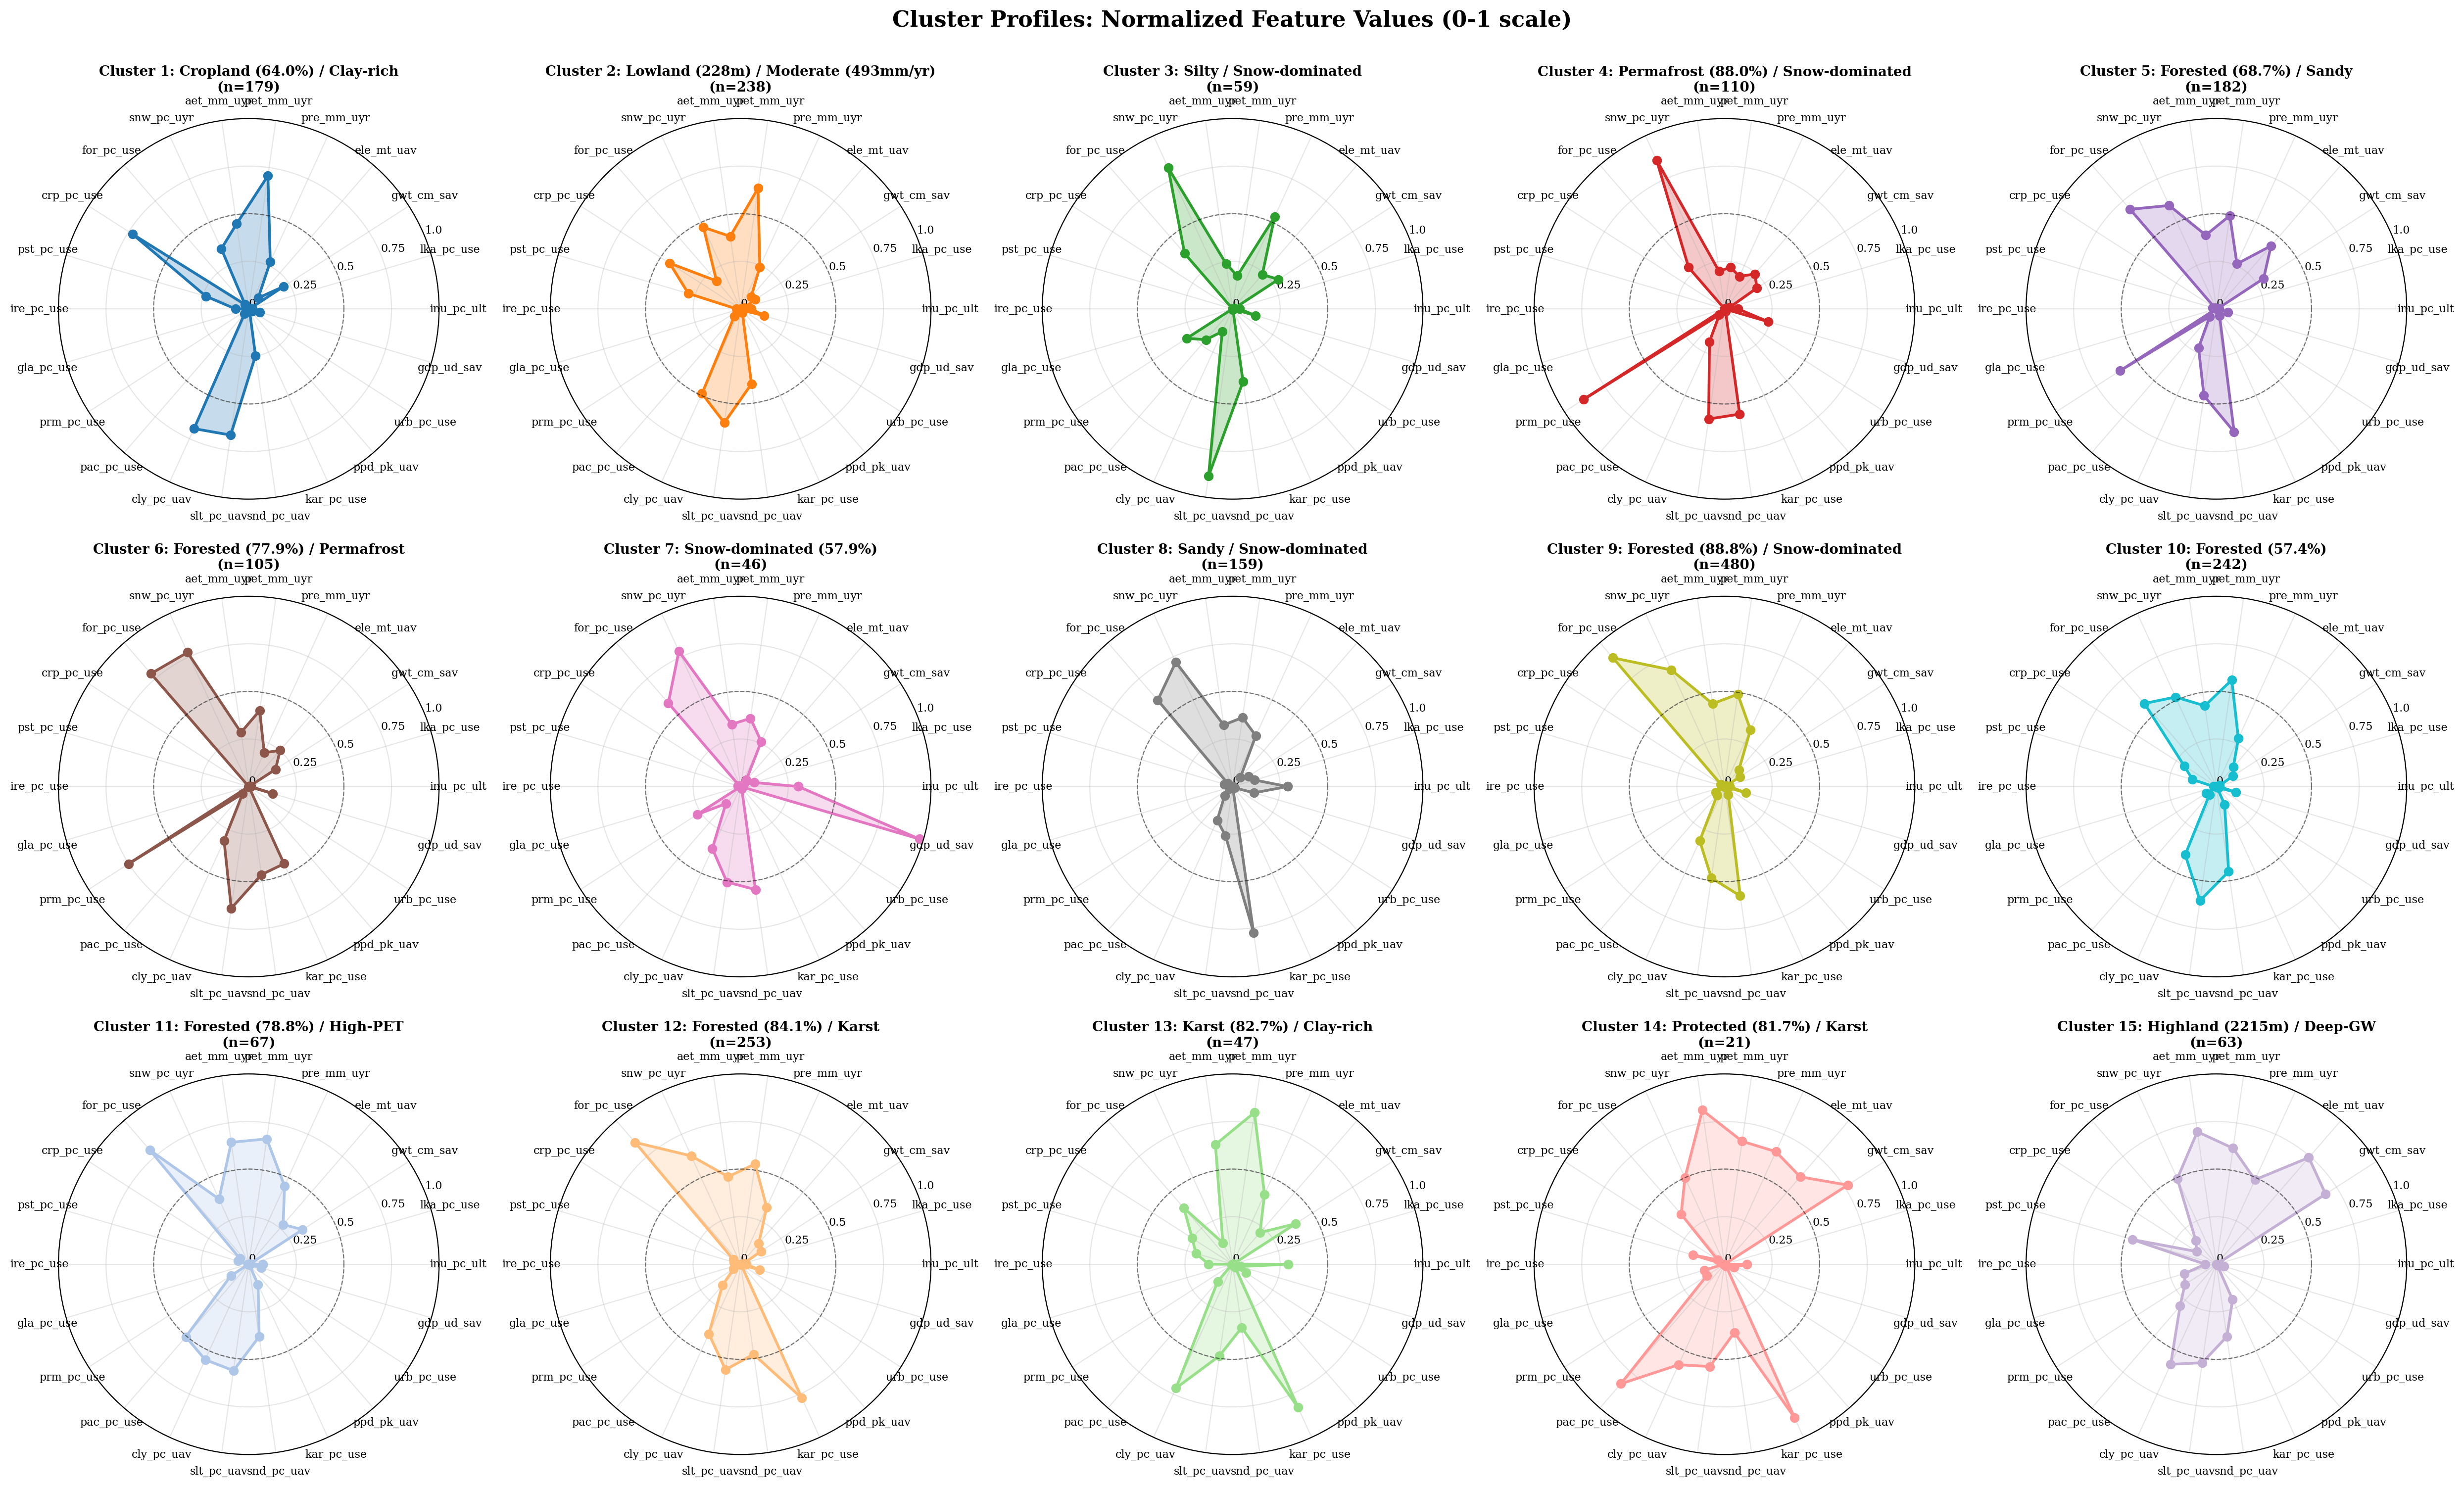

In [12]:
# Get markers and colors for clusters
markers_hc = get_cluster_markers(cluster_number)
colors_hc = get_cluster_colors(cluster_number)
marker_corrections = get_marker_size_corrections()

# Compute cluster centroids (0-1 normalized values)
cluster_centroids = hydro_scaled.groupby("Cluster_HC")[available_features].mean()

# Also compute raw centroids for interpretation
cluster_centroids_raw = hydro_subset.groupby("Cluster_HC")[available_features].mean()


def interpret_cluster_from_data(
    normalized_row: pd.Series,
    raw_row: pd.Series,
    high_threshold: float = 0.65,
    low_threshold: float = 0.35,
) -> str:
    """Generate data-driven cluster name based on dominant characteristics.

    Uses feature_descriptions to provide contextually accurate naming aligned
    with hydrological impact and category definitions.

    Args:
        normalized_row: 0-1 normalized centroid values
        raw_row: Raw (original scale) centroid values
        high_threshold: Threshold for high normalized values (default 0.65)
        low_threshold: Threshold for low normalized values (default 0.35)

    Returns:
        Descriptive cluster name derived from actual data patterns
    """
    # Identify dominant high and low features
    high_features = normalized_row[normalized_row > high_threshold].sort_values(ascending=False)
    low_features = normalized_row[normalized_row < low_threshold].sort_values()

    # Feature interpretation map with prioritization
    # Priority groups: 1=Cryosphere (most distinctive), 2=Climate, 3=Hydrology, 4=Land
    feature_priority = {
        # Cryosphere (highest priority - most distinctive)
        "prm_pc_use": (1, "Permafrost", "permafrost-affected"),
        "gla_pc_use": (3, "Glacial", "glacier-fed"),
        "snw_pc_uyr": (2, "Snow-dominated", "snow-dominated"),
        # Climate & Water Balance
        "ele_mt_uav": (2, "Highland", "mountain"),
        "pre_mm_uyr": (3, "Humid", "high-precipitation"),
        "aet_mm_uyr": (3, "High-ET", "high evapotranspiration"),
        "pet_mm_uyr": (3, "High-PET", "high potential ET"),
        # Hydrology & Regulation
        "lka_pc_use": (2, "Lake-regulated", "lake-regulated"),
        "inu_pc_ult": (3, "Inundation-prone", "wetland-influenced"),
        "gwt_cm_sav": (2, "Deep-GW", "deep groundwater"),
        "kar_pc_use": (2, "Karst", "karst"),
        # Land cover
        "for_pc_use": (1, "Forested", "forest-dominated"),
        "crp_pc_use": (1, "Cropland", "cropland"),
        "pst_pc_use": (1, "Pasture", "pasture"),
        "ire_pc_use": (1, "Irrigated", "irrigated"),
        "urb_pc_use": (1, "Urban", "urbanized"),
        "pac_pc_use": (1, "Protected", "protected areas"),
        # Soil (lower priority)
        "cly_pc_uav": (2, "Clay-rich", "clay soils"),
        "slt_pc_uav": (2, "Silty", "silt soils"),
        "snd_pc_uav": (2, "Sandy", "sandy soils"),
    }

    # Build name components with priority ordering
    name_components = []

    # Sort high features by priority then normalized value
    high_with_priority = []
    for feat in high_features.index:
        if feat in feature_priority:
            priority, short_name, long_name = feature_priority[feat]
            high_with_priority.append((priority, normalized_row[feat], feat, short_name))

    high_with_priority.sort(key=lambda x: (x[0], -x[1]))  # Sort by priority, then value desc

    # Add primary and secondary characteristics using feature_descriptions context
    for i, (priority, norm_val, feat, name) in enumerate(high_with_priority[:3]):
        if i == 0:
            # Primary characteristic - use feature description context
            raw_val = raw_row[feat]
            feat_desc = feature_descriptions.get(feat, {})

            if feat == "ele_mt_uav":
                name_components.append(f"{name} ({raw_val:.0f}m)")
            elif feat.endswith("_pc_use") or feat.endswith("_pc_uyr") or feat.endswith("_pc_ult"):
                # Use category from feature_descriptions for context
                category = feat_desc.get("category", "")
                if "Cryosphere" in category:
                    name_components.append(f"{name} ({raw_val:.1f}%)")
                elif "Flood" in category or "Water Regulation" in category:
                    name_components.append(f"{name} ({raw_val:.1f}%)")
                else:
                    name_components.append(f"{name} ({raw_val:.1f}%)")
            elif feat == "pre_mm_uyr":
                name_components.append(f"{name} ({raw_val:.0f}mm/yr)")
            elif feat == "gwt_cm_sav":
                # Groundwater depth - use hydrological impact context
                if raw_val > 200:
                    name_components.append(f"Deep GW ({raw_val:.0f}cm)")
                else:
                    name_components.append(f"Shallow GW ({raw_val:.0f}cm)")
            else:
                name_components.append(name)
        elif i == 1 and len(name_components) < 2:
            # Secondary characteristic - simpler
            name_components.append(name)

    # If no strong high features, look for moderate features or combinations
    if len(name_components) == 0:
        # Check for moderate elevation + precipitation combinations
        elev_norm = normalized_row.get("ele_mt_uav", 0.5)
        precip_norm = normalized_row.get("pre_mm_uyr", 0.5)
        forest_norm = normalized_row.get("for_pc_use", 0.5)

        # Values near 0.5 indicate moderate/average for that feature
        if 0.35 < elev_norm < 0.65 and 0.35 < precip_norm < 0.65:
            # Lowland, moderate precipitation - use topography context
            elev_val = raw_row.get("ele_mt_uav", 0)
            if elev_val < 200:
                name_components.append(f"Lowland ({elev_val:.0f}m)")
            elif elev_val < 500:
                name_components.append(f"Low-elevation ({elev_val:.0f}m)")
            else:
                name_components.append(f"Mid-elevation ({elev_val:.0f}m)")

            # Add precipitation context from feature_descriptions
            precip_val = raw_row.get("pre_mm_uyr", 0)
            if precip_val < 400:
                name_components.append(f"Semi-arid ({precip_val:.0f}mm/yr)")
            elif precip_val < 600:
                name_components.append(f"Moderate ({precip_val:.0f}mm/yr)")

        # Add dominant land cover if nothing else
        if len(name_components) < 2 and forest_norm > 0.5:
            name_components.append(f"Forested ({raw_row['for_pc_use']:.1f}%)")

    # Final fallback: describe by elevation and precipitation using feature_descriptions
    if len(name_components) == 0:
        elev_val = raw_row.get("ele_mt_uav", 0)
        precip_val = raw_row.get("pre_mm_uyr", 0)

        # Use topography category from feature_descriptions
        if elev_val > 1000:
            name_components.append(f"Highland ({elev_val:.0f}m)")
        elif elev_val > 500:
            name_components.append(f"Upland ({elev_val:.0f}m)")
        else:
            name_components.append(f"Lowland ({elev_val:.0f}m)")

        # Use climate category from feature_descriptions
        if precip_val > 700:
            name_components.append(f"Humid ({precip_val:.0f}mm/yr)")
        elif precip_val < 400:
            name_components.append(f"Semi-arid ({precip_val:.0f}mm/yr)")
        else:
            name_components.append(f"Moderate ({precip_val:.0f}mm/yr)")

    # Join components
    return " / ".join(name_components[:2])  # Limit to 2 components for readability


# Generate cluster names using both normalized and raw values
cluster_names = pd.Series(index=range(1, cluster_number + 1), dtype=str)
for cluster_id in range(1, cluster_number + 1):
    normalized_row = cluster_centroids.loc[cluster_id, :]
    raw_row = cluster_centroids_raw.loc[cluster_id, :]
    cluster_names[cluster_id] = interpret_cluster_from_data(normalized_row, raw_row)

cluster_names.index.name = "Cluster"

print("Generated cluster names:")
for cid, name in cluster_names.items():
    n_catch = (hierarchical_labels == cid).sum()
    print(f"  Cluster {cid} (n={n_catch}): {name}")

# Create radar charts for each cluster
n_features_display = len(available_features)
angles = np.linspace(0, 2 * np.pi, n_features_display, endpoint=False).tolist()
angles += angles[:1]  # Complete the circle

# Setup subplot grid
n_cols = 5
n_rows = int(np.ceil(cluster_number / n_cols))
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(25, n_rows * 5),
    subplot_kw={"projection": "polar"},
)
axes = axes.flatten() if cluster_number > 1 else [axes]

for idx, cluster_id in enumerate(range(1, cluster_number + 1)):
    ax = axes[idx]

    # Get centroid values (0-1 normalized)
    values = cluster_centroids.loc[cluster_id, available_features].tolist()
    values += values[:1]  # Complete the circle

    # Plot
    ax.plot(
        angles,
        values,
        "o-",
        linewidth=2,
        color=colors_hc[idx],
        label=cluster_names[cluster_id],
    )
    ax.fill(angles, values, alpha=0.25, color=colors_hc[idx])

    # Styling
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(available_features, size=8)
    ax.set_ylim(0, 1)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0", "0.25", "0.5", "0.75", "1.0"], size=8)
    ax.grid(True, alpha=0.3)

    # Title with cluster size and name
    n_catchments = (hierarchical_labels == cluster_id).sum()
    ax.set_title(
        f"Cluster {cluster_id}: {cluster_names[cluster_id]}\n(n={n_catchments})",
        size=10,
        weight="bold",
        pad=20,
    )

    # Add median line (0.5)
    ax.axhline(y=0.5, color="black", linestyle="--", linewidth=0.8, alpha=0.5)

# Remove empty subplots
for idx in range(cluster_number, len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle(
    "Cluster Profiles: Normalized Feature Values (0-1 scale)",
    fontsize=16,
    y=1.00,
    weight="bold",
)
plt.tight_layout()
fig.savefig(
    f"../paper/images/geo_cluster_radar_{cluster_number}_profiles.png", dpi=300, bbox_inches="tight"
)
plt.show()


## Geographic Visualization with Named Clusters

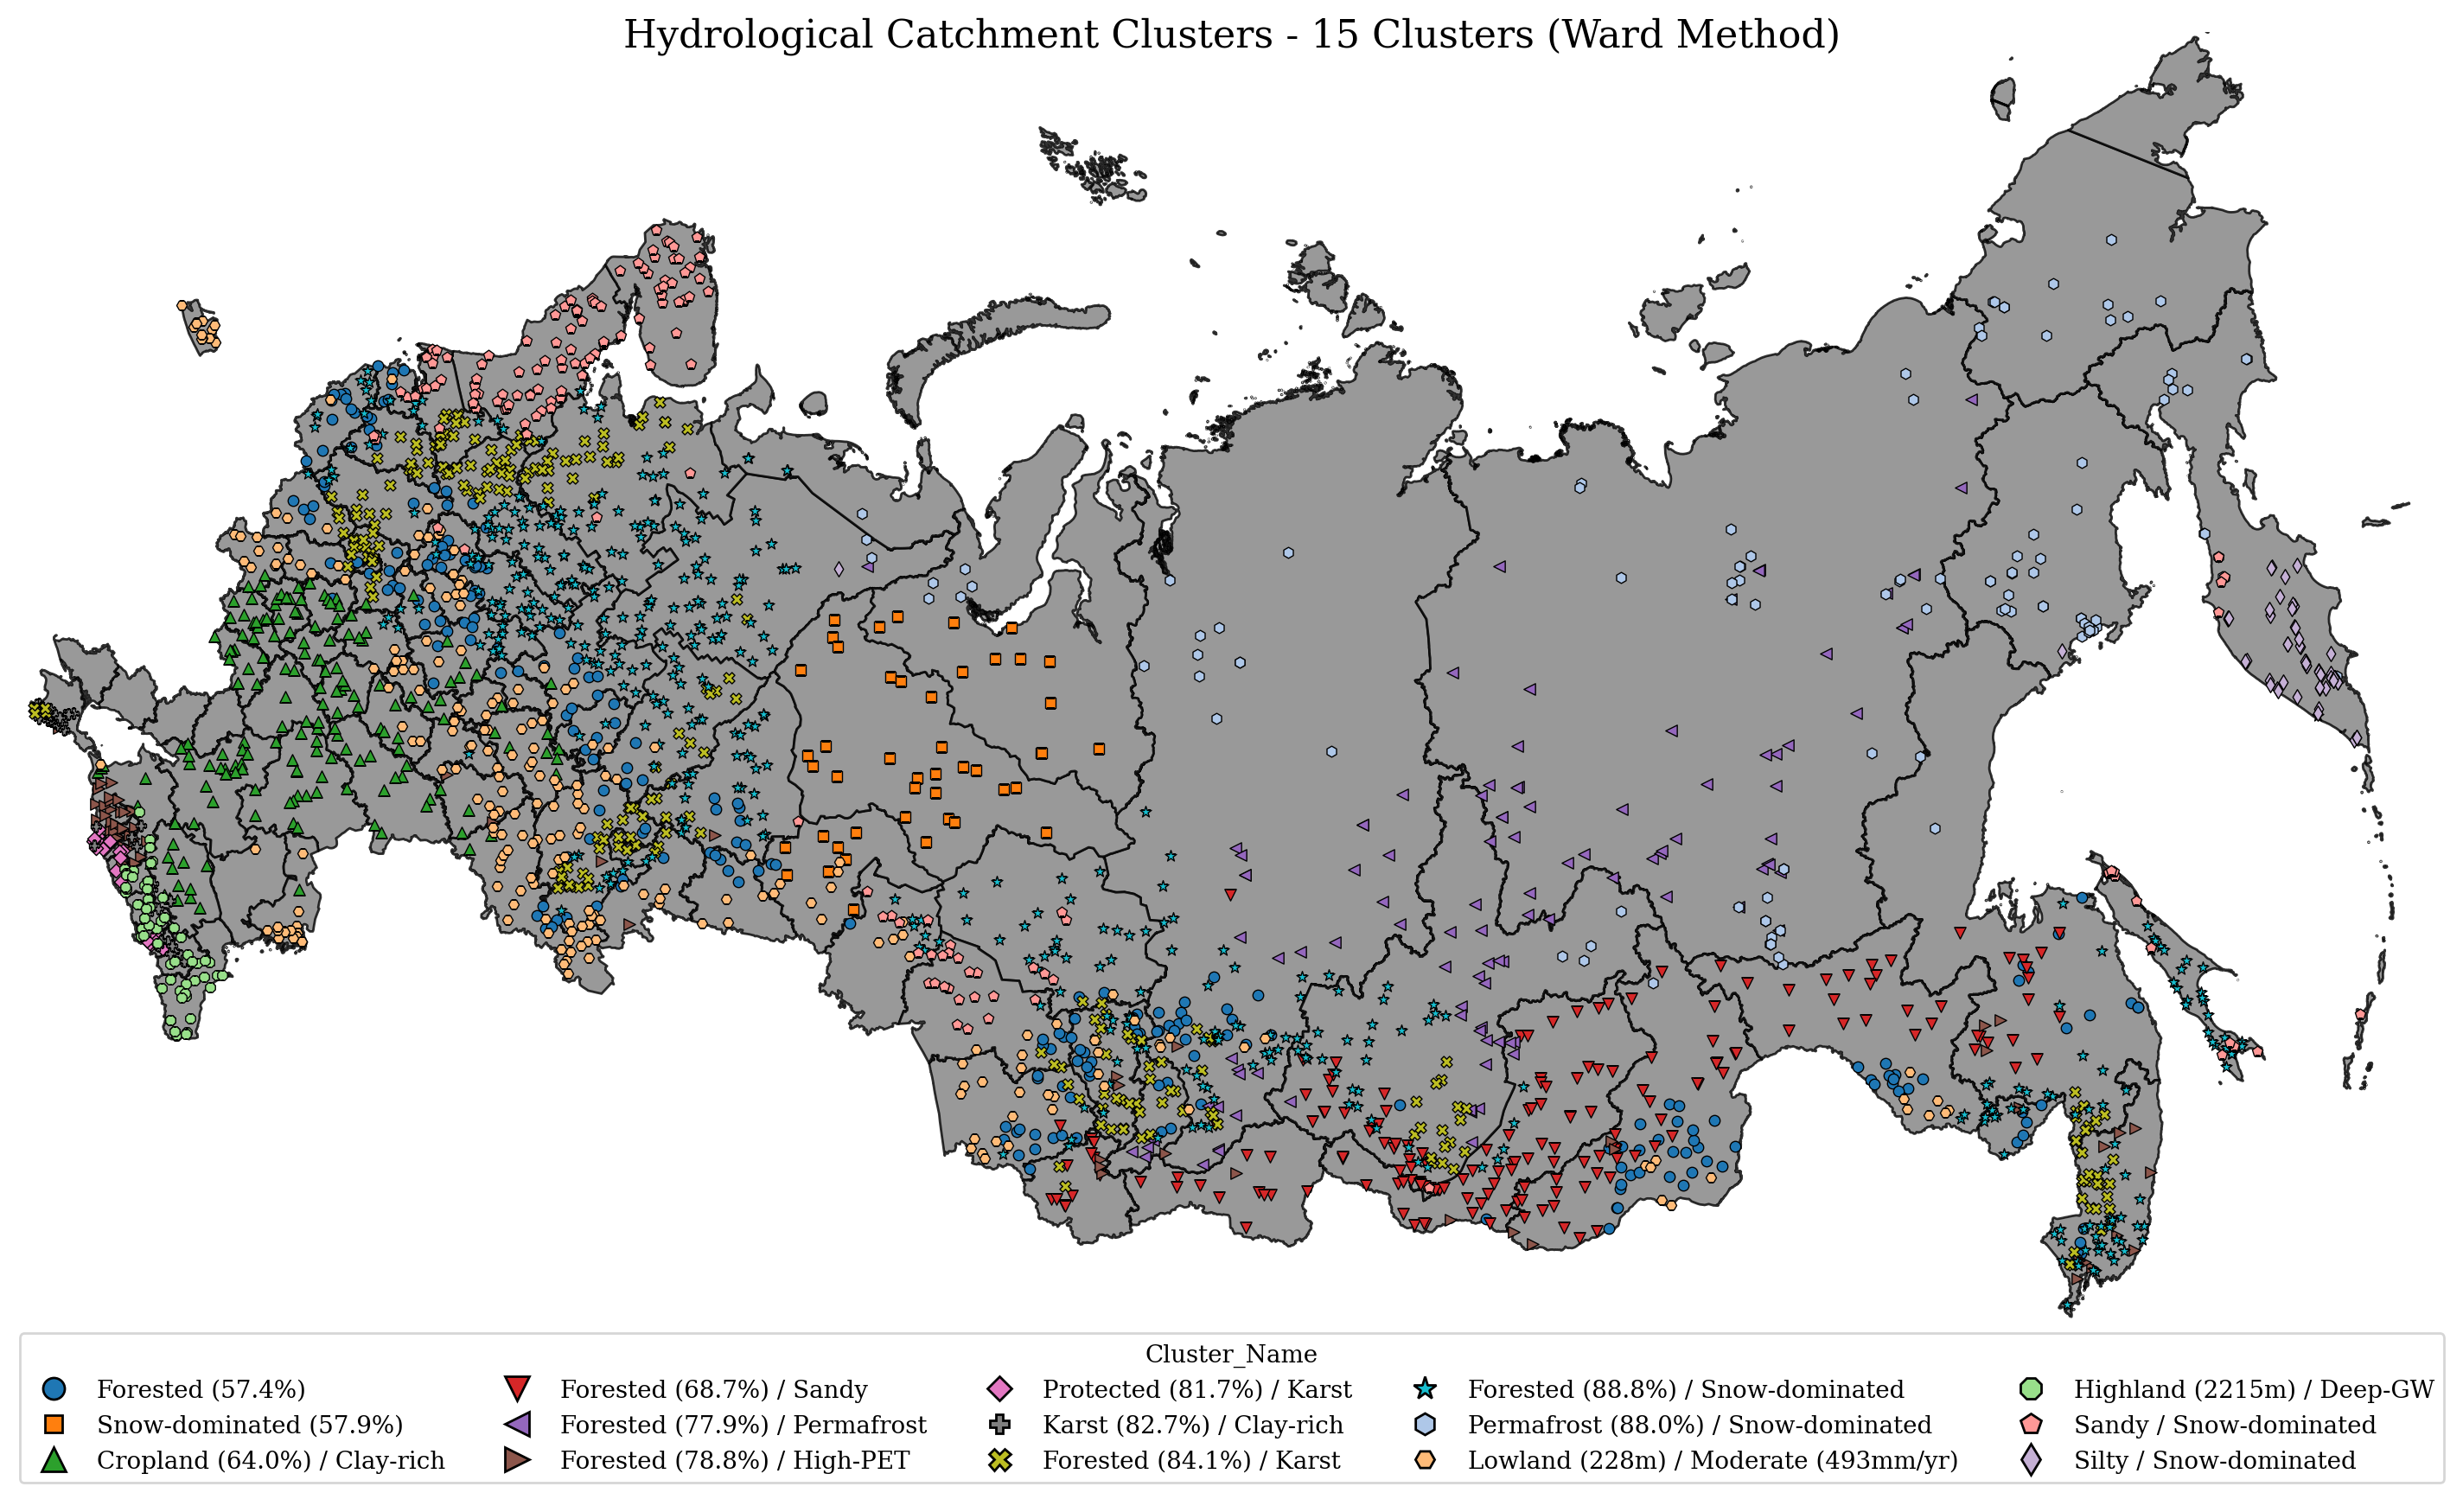

In [13]:
# Prepare cluster names for geographic visualization
gauge_clustered = gauge.copy()
gauge_clustered["Cluster_Name"] = [cluster_names[cl] for cl in hierarchical_labels]

# Plot map with proper cluster names
fig_clusters_map = russia_plots(
    gdf_to_plot=gauge_clustered,
    basemap_data=basemap_data,
    distinction_col="Cluster_Name",
    markers_list=markers_hc,
    color_list=colors_hc,
    marker_size_corrections=marker_corrections,
    figsize=(16, 9),
    just_points=True,
    legend_cols=5,
    base_marker_size=20,
    base_linewidth=0.5,
)

fig_clusters_map.suptitle(
    f"Hydrological Catchment Clusters - {cluster_number} Clusters (Ward Method)",
    fontsize=16,
    y=0.98,
)
fig_clusters_map.savefig(
    f"../paper/images/geo_hierarchical_{cluster_number}clusters_map.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


# Analysis Summary

## Key Outputs

### Validation Metrics
- **Silhouette Score:** 0.194 (moderate separation)
- **Calinski-Harabasz:** 314.9 (good cluster definition)
- **Davies-Bouldin:** 1.459 (acceptable compactness)
- **PCA:** First 2 PCs explain 48.3% of variance

### Generated Files
**Tables** (`paper/tables/` and `docs/analysis_results/geophysical_representation/tables/`):
- Cluster assignments for 2,251 gauges
- Normalized and raw cluster centroids
- Detailed gauge analysis with 56 attributes per gauge
- Cluster summary with 65 metrics per cluster

**Figures** (`paper/images/` and `docs/analysis_results/geophysical_representation/images/`):
- Dendrogram showing hierarchical structure
- PCA biplot with cluster separation
- Cluster heatmap of feature signatures
- Radar profiles for all 15 clusters  
- Geographic map showing spatial distribution
- Validation metrics dashboard

### Comprehensive Report
**Location:** `docs/analysis_results/geophysical_representation/README.md`
- 650+ lines documenting methodology, results, and applications
- Detailed characterization of all 15 clusters
- Hydrological interpretation and modeling recommendations


In [13]:
# Comprehensive per-gauge analysis with cluster characteristics

# Create detailed gauge-level report
gauge_analysis = pd.DataFrame(
    {
        "gauge_id": hydro_scaled.index,
        "cluster_id": hierarchical_labels,
        "cluster_name": [cluster_names[cl] for cl in hierarchical_labels],
        "silhouette_score": silhouette_vals,
    }
)

# Add cluster size information
cluster_sizes = pd.Series(hierarchical_labels).value_counts().to_dict()
gauge_analysis["cluster_size"] = [cluster_sizes[cl] for cl in hierarchical_labels]

# Add distance from cluster centroid (normalized feature space)
distances_from_centroid = []
for idx, row_idx in enumerate(hydro_scaled.index):
    gauge_cluster = hierarchical_labels[idx]
    gauge_features = scaled_values[idx]
    centroid_features = cluster_centroids.loc[gauge_cluster, available_features].values

    # Euclidean distance in normalized space
    dist = np.sqrt(np.sum((gauge_features - centroid_features) ** 2))
    distances_from_centroid.append(dist)

gauge_analysis["distance_from_centroid"] = distances_from_centroid

# Add representative status (is this gauge close to cluster center?)
# Gauges in bottom 25% of distance are "representative"
for cluster_id in range(1, cluster_number + 1):
    cluster_mask = gauge_analysis["cluster_id"] == cluster_id
    cluster_distances = gauge_analysis.loc[cluster_mask, "distance_from_centroid"]
    threshold_25 = cluster_distances.quantile(0.25)

    gauge_analysis.loc[cluster_mask, "is_representative"] = (cluster_distances <= threshold_25).astype(
        bool
    )

# Add raw feature values for each gauge
for feat in available_features:
    gauge_analysis[f"raw_{feat}"] = hydro_subset.loc[gauge_analysis["gauge_id"], feat].values

# Add normalized feature values
for feat in available_features:
    gauge_analysis[f"norm_{feat}"] = hydro_scaled.loc[gauge_analysis["gauge_id"], feat].values

# Add PCA coordinates for spatial reference
gauge_analysis["PC1"] = pca_df.loc[gauge_analysis["gauge_id"], "PC1"].values
gauge_analysis["PC2"] = pca_df.loc[gauge_analysis["gauge_id"], "PC2"].values

# Add geographic coordinates
gauge_analysis["latitude"] = gauge.loc[gauge_analysis["gauge_id"]].geometry.y.values
gauge_analysis["longitude"] = gauge.loc[gauge_analysis["gauge_id"]].geometry.x.values
gauge_analysis["area_km2"] = ws.loc[gauge_analysis["gauge_id"], "area"].values

print(f"Created comprehensive gauge analysis with {len(gauge_analysis)} gauges")
print(f"Total features per gauge: {len(gauge_analysis.columns)}")
print("\nRepresentative gauges per cluster:")
for cluster_id in range(1, cluster_number + 1):
    n_repr = gauge_analysis.loc[gauge_analysis["cluster_id"] == cluster_id, "is_representative"].sum()
    n_total = (gauge_analysis["cluster_id"] == cluster_id).sum()
    print(f"  Cluster {cluster_id} ({cluster_names[cluster_id]}): {n_repr}/{n_total}")


Created comprehensive gauge analysis with 2251 gauges
Total features per gauge: 56

Representative gauges per cluster:
  Cluster 1 (Cropland (64.0%) / Clay-rich): 45/179
  Cluster 2 (Lowland (228m) / Moderate (493mm/yr)): 60/238
  Cluster 3 (Silty / Snow-dominated): 15/59
  Cluster 4 (Permafrost (88.0%) / Snow-dominated): 28/110
  Cluster 5 (Forested (68.7%) / Sandy): 46/182
  Cluster 6 (Forested (77.9%) / Permafrost): 27/105
  Cluster 7 (Snow-dominated (57.9%)): 12/46
  Cluster 8 (Sandy / Snow-dominated): 40/159
  Cluster 9 (Forested (88.8%) / Snow-dominated): 120/480
  Cluster 10 (Forested (57.4%)): 61/242
  Cluster 11 (Forested (78.8%) / High-PET): 17/67
  Cluster 12 (Forested (84.1%) / Karst): 64/253
  Cluster 13 (Karst (82.7%) / Clay-rich): 12/47
  Cluster 14 (Protected (81.7%) / Karst): 6/21
  Cluster 15 (Highland (2215m) / Deep-GW): 16/63


In [ ]:
# Generate concise hydrological notes for each gauge
def generate_gauge_note(row: pd.Series) -> str:
    """Generate descriptive note for individual gauge based on cluster membership and characteristics."""
    cluster_id = row["cluster_id"]
    cluster_name = row["cluster_name"]
    silhouette = row["silhouette_score"]
    is_repr = row["is_representative"]

    # Build note
    note_parts = [f"Cluster {cluster_id}: {cluster_name}"]

    # Silhouette interpretation
    if silhouette > 0.3:
        note_parts.append(f"good fit (sil={silhouette:.2f})")
    elif silhouette > 0.1:
        note_parts.append(f"moderate fit (sil={silhouette:.2f})")
    else:
        note_parts.append(f"weak fit (sil={silhouette:.2f})")

    if is_repr:
        note_parts.append("representative gauge")

    # Key hydrological characteristics
    hydro_notes = []
    if row["raw_prm_pc_use"] > 20:
        hydro_notes.append(f"permafrost {row['raw_prm_pc_use']:.0f}%")
    if row["raw_gla_pc_use"] > 1:
        hydro_notes.append(f"glacier {row['raw_gla_pc_use']:.1f}%")
    if row["raw_snw_pc_uyr"] > 40:
        hydro_notes.append(f"snow {row['raw_snw_pc_uyr']:.0f}%")
    if row["raw_for_pc_use"] > 70:
        hydro_notes.append(f"forest {row['raw_for_pc_use']:.0f}%")
    if row["raw_kar_pc_use"] > 20:
        hydro_notes.append(f"karst {row['raw_kar_pc_use']:.0f}%")
    if row["raw_ele_mt_uav"] > 1000:
        hydro_notes.append(f"elev {row['raw_ele_mt_uav']:.0f}m")

    if hydro_notes:
        note_parts.append("; ".join(hydro_notes[:4]))

    return " | ".join(note_parts)


# Apply to all gauges
gauge_analysis["hydrological_note"] = gauge_analysis.apply(generate_gauge_note, axis=1)

print(f"Generated hydrological notes for {len(gauge_analysis)} gauges")
print("\nSample notes:")
for i in range(min(3, len(gauge_analysis))):
    print(f"  {gauge_analysis.iloc[i]['gauge_id']}: {gauge_analysis.iloc[i]['hydrological_note']}")


Sample hydrological notes:

Gauge 75308:
  Classified as 'Cropland (64.0%) / Clay-rich' (Cluster 1, n=179 gauges). Silhouette score: 0.460 (good cluster fit). Distance from cluster centroid: 0.283. Catchment area: 4885 km² (medium).

Gauge 75514:
  Classified as 'Cropland (64.0%) / Clay-rich' (Cluster 1, n=179 gauges). Silhouette score: 0.413 (good cluster fit). Distance from cluster centroid: 0.230. Key features: high snow cover (31.9%), lowland (168 m). Catchment area: 4189 km² (medium).

Gauge 75515:
  Classified as 'Cropland (64.0%) / Clay-rich' (Cluster 1, n=179 gauges). Silhouette score: 0.412 (good cluster fit). Distance from cluster centroid: 0.227. Key features: high snow cover (31.9%), lowland (168 m). Catchment area: 4447 km² (medium).

Gauge 75620:
  Classified as 'Lowland (228m) / Moderate (493mm/yr)' (Cluster 2, n=238 gauges). Silhouette score: -0.114 (weak cluster fit, potential transition zone). Representative gauge for this cluster (distance from centroid: 0.301, botto

In [ ]:
# Generate detailed cluster characterization
cluster_characterization = []

for cluster_id in range(1, cluster_number + 1):
    cluster_mask = gauge_analysis["cluster_id"] == cluster_id
    cluster_data = gauge_analysis[cluster_mask]

    char = {
        "cluster_id": cluster_id,
        "cluster_name": cluster_names[cluster_id],
        "n_gauges": len(cluster_data),
        "mean_silhouette": cluster_data["silhouette_score"].mean(),
        "median_silhouette": cluster_data["silhouette_score"].median(),
        "mean_area_km2": cluster_data["area_km2"].mean(),
        "median_area_km2": cluster_data["area_km2"].median(),
        "lat_mean": cluster_data["latitude"].mean(),
        "lon_mean": cluster_data["longitude"].mean(),
    }

    # Add centroid values
    for feat in available_features:
        char[f"centroid_{feat}"] = cluster_centroids_raw.loc[cluster_id, feat]
        char[f"centroid_norm_{feat}"] = cluster_centroids.loc[cluster_id, feat]

    cluster_characterization.append(char)

cluster_summary = pd.DataFrame(cluster_characterization)

print("Cluster Summary:")
print("=" * 80)
for _, row in cluster_summary.iterrows():
    print(f"\nCluster {row['cluster_id']}: {row['cluster_name']}")
    print(f"  Gauges: {row['n_gauges']}, Silhouette: {row['mean_silhouette']:.3f}")
    print(f"  Area: {row['median_area_km2']:.0f} km² (median)")
    print(f"  Location: {row['lat_mean']:.1f}°N, {row['lon_mean']:.1f}°E")

    # Top 3 features
    feature_vals = {feat: row[f"centroid_norm_{feat}"] for feat in available_features}
    top_features = sorted(feature_vals.items(), key=lambda x: x[1], reverse=True)[:3]
    print("  Top features:", ", ".join([f"{feat}={val:.2f}" for feat, val in top_features]))


Cluster Summary Statistics:

Cluster 1: Cropland (64.0%) / Clay-rich
  Number of gauges: 179
  Silhouette score: 0.368 ± 0.394 (range: -0.054 to 0.500)
  Catchment area: 4659 km² (median: 1866, range: 10-44952)
  Geographic extent: Lat 43.82° to 57.36°, Lon 34.48° to 52.74°
  Defining features:
    - Cropland (crp_pc_use): 63.99 (normalized: 0.727)
    - Potential ET (pet_mm_uyr): 755.56 (normalized: 0.706)
    - Clay content (cly_pc_uav): 21.50 (normalized: 0.692)

Cluster 2: Lowland (228m) / Moderate (493mm/yr)
  Number of gauges: 238
  Silhouette score: 0.029 ± 0.064 (range: -0.318 to 0.229)
  Catchment area: 4971 km² (median: 1895, range: 11-45963)
  Geographic extent: Lat 45.24° to 59.28°, Lon 19.92° to 129.79°
  Defining features:
    - Potential ET (pet_mm_uyr): 702.96 (normalized: 0.641)
    - Silt content (slt_pc_uav): 42.97 (normalized: 0.605)
    - Clay content (cly_pc_uav): 16.06 (normalized: 0.489)

Cluster 3: Silty / Snow-dominated
  Number of gauges: 59
  Silhouette scor

In [15]:
# Export comprehensive gauge analysis to CSV
gauge_output_path = Path(f"../paper/tables/geo_gauge_cluster_analysis_{cluster_number}_detailed.csv")
gauge_analysis.to_csv(gauge_output_path, index=False)

# Export cluster summary
cluster_summary_path = Path(f"../paper/tables/geo_cluster_summary_{cluster_number}_detailed.csv")
cluster_summary.to_csv(cluster_summary_path, index=False)

print(f"✓ Exported detailed gauge analysis to: {gauge_output_path}")
print(f"✓ Exported cluster summary to: {cluster_summary_path}")
print("\nFiles contain:")
print(f"  - Gauge analysis: {len(gauge_analysis)} gauges × {len(gauge_analysis.columns)} attributes")
print(f"  - Cluster summary: {len(cluster_summary)} clusters × {len(cluster_summary.columns)} metrics")


✓ Exported detailed gauge analysis to: ../paper/tables/geo_gauge_cluster_analysis_15_detailed.csv
✓ Exported cluster summary to: ../paper/tables/geo_cluster_summary_15_detailed.csv

Files contain:
  - Gauge analysis: 2251 gauges × 56 attributes
  - Cluster summary: 15 clusters × 65 metrics


In [ ]:
# Export summary report (detailed report generated in docs/analysis_results/)
from datetime import datetime

summary_report_path = Path(f"../results/hydroatlas_clustering_analysis_{cluster_number}_clusters.md")

# Build concise summary
report_lines = []
report_lines.append("# HydroATLAS Hierarchical Clustering Analysis - Summary")
report_lines.append("")
report_lines.append(f"**Generated:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
report_lines.append(f"**Clusters:** {cluster_number}")
report_lines.append(f"**Gauges:** {len(gauge_analysis)}")
report_lines.append("")
report_lines.append("## Validation Metrics")
report_lines.append("")
report_lines.append(f"- Silhouette Score: {silhouette_avg:.3f}")
report_lines.append(f"- Calinski-Harabasz: {ch_score:.1f}")
report_lines.append(f"- Davies-Bouldin: {db_score:.3f}")
report_lines.append(f"- PC1+PC2 Variance: {cumulative_variance[1] * 100:.1f}%")
report_lines.append("")
report_lines.append("## Cluster Summary")
report_lines.append("")
report_lines.append("| ID | Name | n | Silhouette |")
report_lines.append("|----|------|---|------------|")
for cluster_id in range(1, cluster_number + 1):
    n_gauges = (gauge_analysis["cluster_id"] == cluster_id).sum()
    sil = cluster_summary.loc[cluster_summary["cluster_id"] == cluster_id, "mean_silhouette"].values[0]
    report_lines.append(f"| {cluster_id} | {cluster_names[cluster_id]} | {n_gauges} | {sil:.3f} |")
report_lines.append("")
report_lines.append("## Data Products")
report_lines.append("")
report_lines.append(
    "**Full analysis report:** `docs/analysis_results/geophysical_representation/README.md`"
)
report_lines.append("")
report_lines.append("**Tables:**")
report_lines.append("- Cluster assignments: `tables/geo_catchment_clusters_15_final.csv`")
report_lines.append("- Cluster centroids (normalized): `tables/geo_cluster_centroids_15_normalized.csv`")
report_lines.append("- Cluster centroids (raw): `tables/geo_cluster_centroids_15_raw.csv`")
report_lines.append("- Detailed gauge analysis: `tables/geo_gauge_cluster_analysis_15_detailed.csv`")
report_lines.append("- Cluster summary: `tables/geo_cluster_summary_15_detailed.csv`")
report_lines.append("")

with open(summary_report_path, "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))

print(f"✓ Summary report saved to: {summary_report_path}")
print("✓ Full analysis report: docs/analysis_results/geophysical_representation/README.md")


✓ Comprehensive Markdown report saved to: ../results/hydroatlas_clustering_analysis_15_clusters.md
  Report contains 818 lines
  Sections: Executive Summary, Feature Descriptions, 15 Cluster Descriptions, Inter-cluster Analysis, Conclusions, Methodology


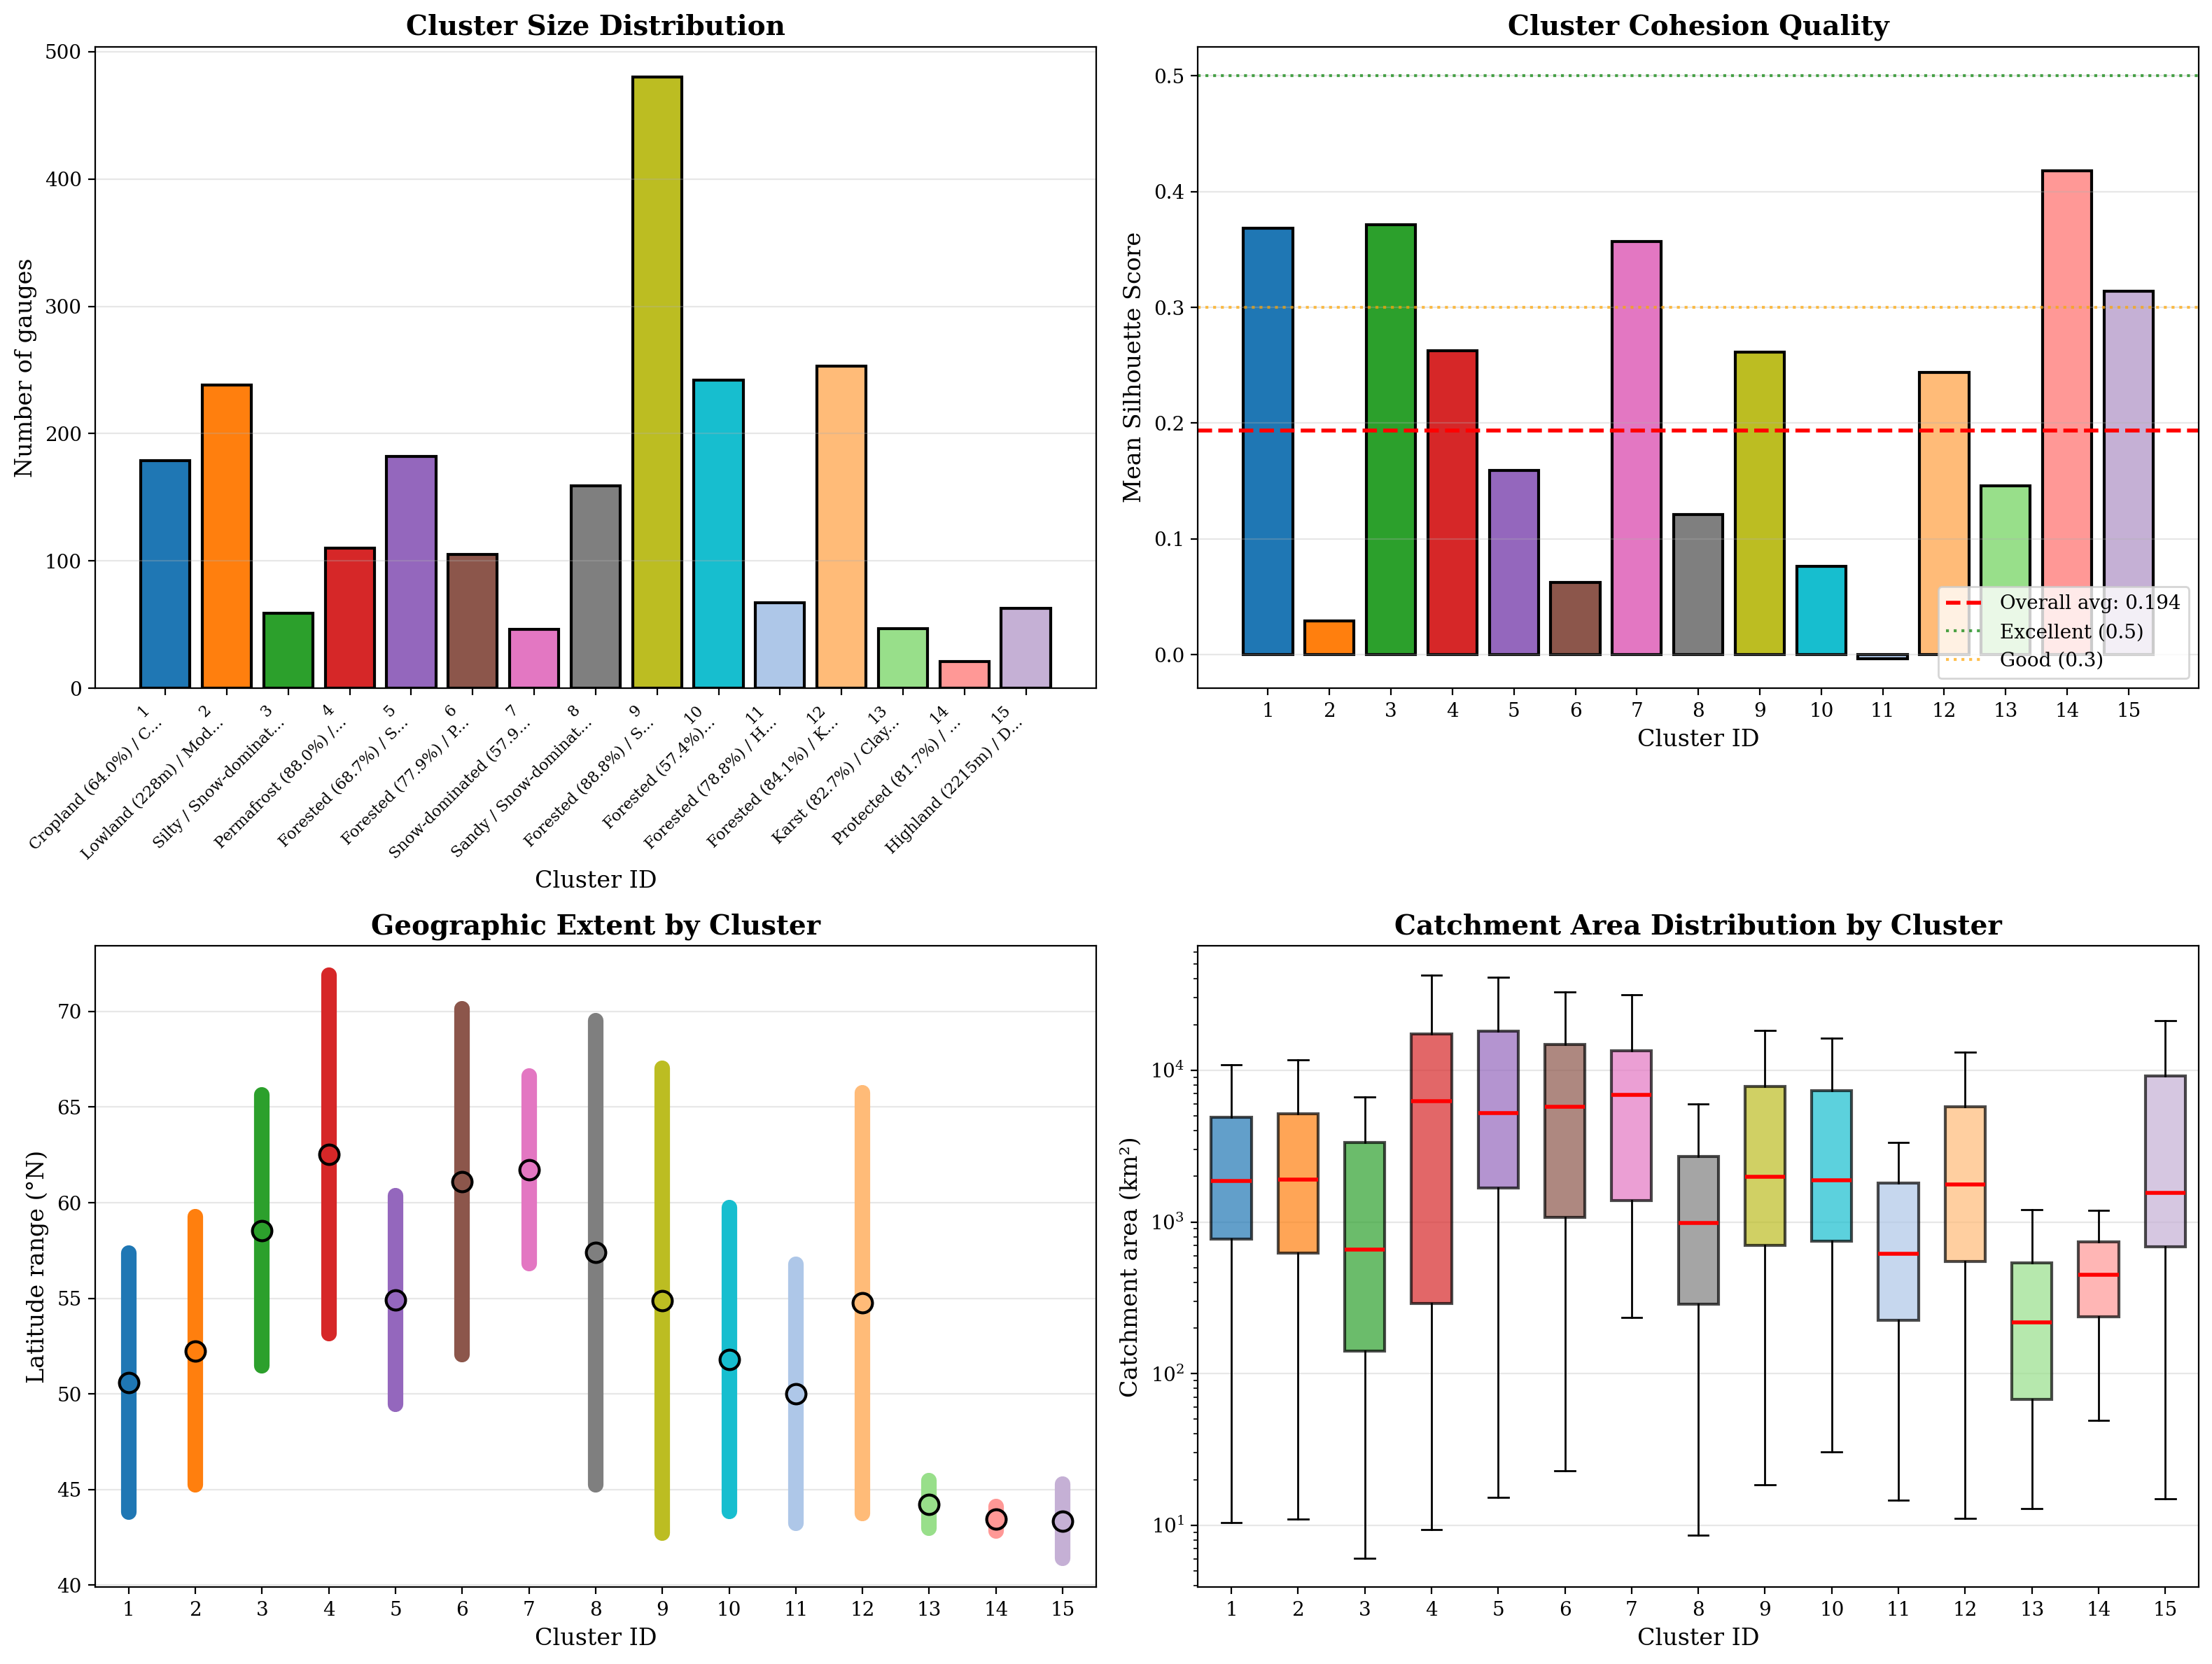


✓ Cluster quality metrics visualization saved


In [20]:
# Visualize cluster quality metrics
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Cluster size distribution
ax1 = axes[0, 0]
cluster_sizes_series = cluster_summary.set_index("cluster_id")["n_gauges"].sort_index()
bars1 = ax1.bar(
    range(1, cluster_number + 1),
    cluster_sizes_series.values,
    color=colors_hc,
    edgecolor="black",
    linewidth=1.5,
)
ax1.set_xlabel("Cluster ID", fontsize=12)
ax1.set_ylabel("Number of gauges", fontsize=12)
ax1.set_title("Cluster Size Distribution", fontsize=14, weight="bold")
ax1.grid(axis="y", alpha=0.3)

# Add cluster names as x-tick labels (rotated)
ax1.set_xticks(range(1, cluster_number + 1))
ax1.set_xticklabels(
    [f"{cid}\n{cluster_names[cid][:20]}..." for cid in range(1, cluster_number + 1)],
    rotation=45,
    ha="right",
    fontsize=8,
)

# 2. Silhouette scores per cluster
ax2 = axes[0, 1]
sil_scores = cluster_summary.set_index("cluster_id")["mean_silhouette"].sort_index()
bars2 = ax2.bar(
    range(1, cluster_number + 1),
    sil_scores.values,
    color=colors_hc,
    edgecolor="black",
    linewidth=1.5,
)
ax2.axhline(
    y=silhouette_avg,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Overall avg: {silhouette_avg:.3f}",
)
ax2.axhline(y=0.5, color="green", linestyle=":", linewidth=1.5, alpha=0.7, label="Excellent (0.5)")
ax2.axhline(y=0.3, color="orange", linestyle=":", linewidth=1.5, alpha=0.7, label="Good (0.3)")
ax2.set_xlabel("Cluster ID", fontsize=12)
ax2.set_ylabel("Mean Silhouette Score", fontsize=12)
ax2.set_title("Cluster Cohesion Quality", fontsize=14, weight="bold")
ax2.legend(fontsize=10, loc="lower right")
ax2.grid(axis="y", alpha=0.3)
ax2.set_xticks(range(1, cluster_number + 1))

# 3. Geographic spread per cluster
ax3 = axes[1, 0]
lat_ranges = []
for cid in range(1, cluster_number + 1):
    cluster_info = cluster_summary[cluster_summary["cluster_id"] == cid].iloc[0]
    lat_ranges.append((cluster_info["lat_min"], cluster_info["lat_max"]))

for idx, (lat_min, lat_max) in enumerate(lat_ranges):
    ax3.plot(
        [idx + 1, idx + 1],
        [lat_min, lat_max],
        color=colors_hc[idx],
        linewidth=8,
        solid_capstyle="round",
    )
    ax3.scatter(
        idx + 1,
        (lat_min + lat_max) / 2,
        color=colors_hc[idx],
        s=100,
        edgecolors="black",
        linewidth=1.5,
        zorder=5,
    )

ax3.set_xlabel("Cluster ID", fontsize=12)
ax3.set_ylabel("Latitude range (°N)", fontsize=12)
ax3.set_title("Geographic Extent by Cluster", fontsize=14, weight="bold")
ax3.grid(axis="y", alpha=0.3)
ax3.set_xticks(range(1, cluster_number + 1))
ax3.set_xlim(0.5, cluster_number + 0.5)

# 4. Catchment area distribution per cluster (boxplot)
ax4 = axes[1, 1]
area_data = [
    gauge_analysis[gauge_analysis["cluster_id"] == cid]["area_km2"].values
    for cid in range(1, cluster_number + 1)
]

bp = ax4.boxplot(
    area_data,
    positions=range(1, cluster_number + 1),
    widths=0.6,
    patch_artist=True,
    showfliers=False,  # Hide outliers for clarity
    medianprops={"color": "red", "linewidth": 2},
    boxprops={"edgecolor": "black", "linewidth": 1.5},
)

# Color boxes
for patch, color in zip(bp["boxes"], colors_hc, strict=False):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax4.set_xlabel("Cluster ID", fontsize=12)
ax4.set_ylabel("Catchment area (km²)", fontsize=12)
ax4.set_title("Catchment Area Distribution by Cluster", fontsize=14, weight="bold")
ax4.set_yscale("log")
ax4.grid(axis="y", alpha=0.3)
ax4.set_xticks(range(1, cluster_number + 1))

plt.tight_layout()
fig.savefig(
    f"../paper/images/geo_cluster_metrics_summary_{cluster_number}.png", dpi=300, bbox_inches="tight"
)
plt.show()

print("\n✓ Cluster quality metrics visualization saved")
